# Task 4 — Algorithmic Trading Strategies

This notebook designs and evaluates trading strategies and portfolio allocation on a multi-asset dataset. All validation uses walk-forward pseudo-OoS within the IS window — the true OoS is never examined.

**Structure:**
1. Data and IS window definition
2. Strategy framework and signal convention
3. Five strategies with mathematical definitions
4. In-sample performance (default parameters)
5. Parameter tuning via grid search
6. Overfitting — what it is and why it matters
7. Evaluation metrics
8. Walk-forward validation (pseudo-OoS)
9. Summary
10. Portfolio allocation — efficient frontier and walk-forward MVP

In [1]:
from pathlib import Path
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

repo_root = Path.cwd().parent
sys.path.append(str(repo_root))

from config.plot_config import plot_config
from Subtasks.series_analysis import PriceAnalysis

output = plot_config() / "task4"
output.mkdir(exist_ok=True)

analysis   = PriceAnalysis.from_csv("spiff_data-2.csv").clean()
prices_raw = analysis.prices
print(f"Loaded {len(prices_raw)} days x {len(prices_raw.columns)} assets: {list(prices_raw.columns)}")
prices_raw.head()


Loaded 5456 days x 7 assets: ['gurkor', 'guitars', 'slingshots', 'stocks', 'sugar', 'water', 'tranquillity']


,gurkor,guitars,slingshots,stocks,sugar,water,tranquillity
day,,,,,,,
1,6.154653,2.794285,2.136536,10.653684,3.324896,3.896149,7.755880
2,6.189623,2.843068,2.113582,10.674465,3.355736,3.899915,7.781310
3,6.168641,2.839644,2.116336,10.822372,3.336461,3.897404,7.886205
4,6.156401,2.823384,2.096137,10.848804,3.288274,3.901170,7.848061
5,6.124929,2.832798,2.099810,10.860731,3.303694,3.905355,7.883026


## 1. Data and IS/OoS Split

### Data quality

The raw dataset has two problematic regions:

- **Days 0-1499**: heavy missingness across most assets -- too few observations for reliable rolling indicators.
- **Days 5000+**: a ~200-day trailing gap.

We restrict to **days 1500-4999** (3500 observations), the densest continuous block.

**Remaining gaps:** within this window there are 3 isolated single-day missing rows (around days 2836, 3430, and 4118). These correspond to non-trading days (e.g. market holidays). We **forward-fill** them: the price on a missing day is assumed unchanged from the prior close, contributing zero log-return on the next day. This is causal (looks only backward) and can safely be applied before the split.

### IS/OoS split

We split 70 / 30:

| Window | Purpose |
|--------|--------|
| **In-sample (IS)** -- first 70% | Strategy exploration, indicator choice, parameter selection |
| **Out-of-sample (OoS)** -- last 30% | Held out; examined exactly once at the end |

**Analysis discipline:** all strategy evaluation and parameter validation is performed on the IS window only, using walk-forward sub-folds as pseudo-OoS. The true OoS window is held out and not examined.


NaN cells before ffill: 21 (3*7=21 expected from placeholder values)
NaN cells after  ffill: 0

Clean window : day 1501 - 5256  (3756 obs)
IS           : day 1501 - 4129  (2629 obs, 70%)
OoS          : day 4130 - 5256  (1127 obs, 30%)


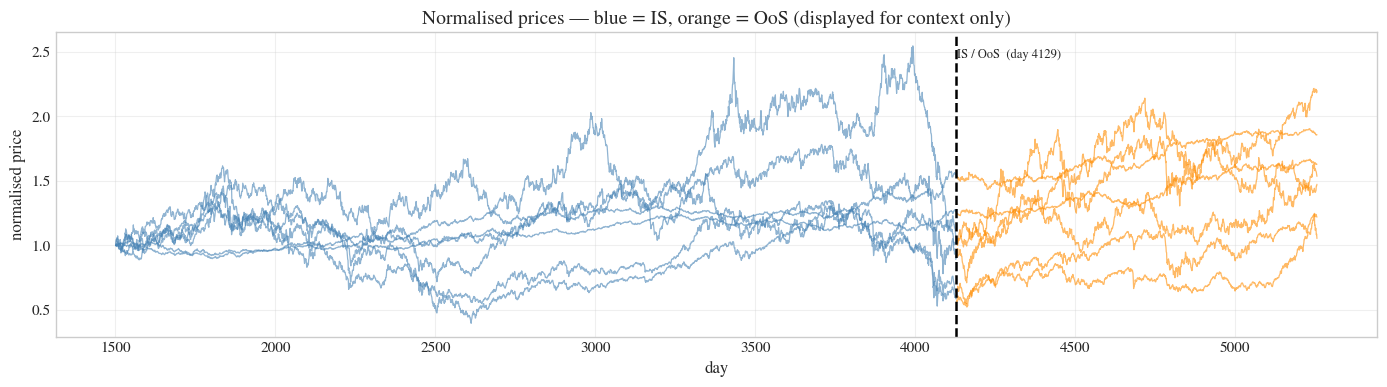

In [2]:
DATA_START = 1500
DATA_END   = 5256
IS_FRAC    = 0.70

prices_clean = prices_raw.iloc[DATA_START:DATA_END].copy()

n_before = prices_clean.isna().sum().sum()
prices_clean = prices_clean.ffill()
n_after  = prices_clean.isna().sum().sum()
print(f"NaN cells before ffill: {n_before} (3*7=21 expected from placeholder values)")
print(f"NaN cells after  ffill: {n_after}")
assert n_after == 0, "Unexpected NaNs remain after forward-fill"

n_clean   = len(prices_clean)
is_size   = int(n_clean * IS_FRAC)
prices_is  = prices_clean.iloc[:is_size]
prices_oos = prices_clean.iloc[is_size:]
split_day  = prices_is.index[-1]

print(f"\nClean window : day {prices_clean.index[0]} - {prices_clean.index[-1]}  ({n_clean} obs)")
print(f"IS           : day {prices_is.index[0]} - {split_day}  ({len(prices_is)} obs, {IS_FRAC:.0%})")
print(f"OoS          : day {prices_oos.index[0]} - {prices_oos.index[-1]}  ({len(prices_oos)} obs, {1-IS_FRAC:.0%})")

fig, ax = plt.subplots(figsize=(14, 4))
for col in prices_is.columns:
    base = prices_is[col].iloc[0]
    ax.plot(prices_is.index,  prices_is[col]  / base, color="steelblue",  alpha=0.6, linewidth=0.9)
    ax.plot(prices_oos.index, prices_oos[col] / base, color="darkorange", alpha=0.6, linewidth=0.9)
ax.axvline(split_day, color="black", linewidth=1.8, linestyle="--")
ax.text(split_day + 2, ax.get_ylim()[1] * 0.95, f"IS / OoS  (day {split_day})", fontsize=9, va="top")
ax.set_title("Normalised prices — blue = IS, orange = OoS (displayed for context only)")
ax.set_xlabel("day"); ax.set_ylabel("normalised price"); ax.grid(True, alpha=0.3)
asset_colors = dict(zip(prices_is.columns, plt.cm.tab10.colors))

plt.tight_layout()
plt.savefig(output / "is_oos_split.png", bbox_inches="tight")
plt.show()


## 2. Strategy Framework

### Long-only signals

All strategies produce a **binary position** for each asset each day:

| Signal | Position | Meaning |
|--------|----------|---------|
| **1** | Long | Buy or hold the asset |
| **0** | Flat | Sell / hold cash |

### One-day lag -- preventing look-ahead bias

Today's **position** must be set by **yesterday's** signal. If the indicator at close of day $t$ says "buy", we enter at the open of day $t+1$ and earn the return on day $t+1$:

$$\text{position}_t = s_{t-1}$$

where $s_t$ is the raw indicator computed from prices through day $t$. This is implemented by `.shift(1)` at the end of every signal function. Forgetting the shift creates **look-ahead bias** -- the strategy appears to trade on information it cannot yet have.

### The apply_signal function

`apply_signal` is **strategy-agnostic**. It accepts any position DataFrame and computes:

$$r^s_t = \text{position}_t \cdot \log\!\left(\frac{P_t}{P_{t-1}}\right)$$

Swapping in a new strategy only requires writing a new signal function -- `apply_signal`, `grid_search`, and `walk_forward` all work unchanged.


In [3]:
def apply_signal(signal: pd.DataFrame, prices: pd.DataFrame) -> dict:
    """
    Convert any position signal into strategy returns.

    Parameters
    ----------
    signal : DataFrame of positions {0, 1}, same index/columns as prices
    prices : DataFrame of price levels (log-returns computed internally)

    Returns
    -------
    dict with keys:
        signals    -- the input signal, unchanged
        returns    -- daily strategy log-returns (position_t x log_return_t)
        cumulative -- cumsum of returns (log-scale equity curve)
    """
    log_ret   = np.log(prices).diff()
    strat_ret = signal * log_ret
    return {
        "signals":    signal,
        "returns":    strat_ret,
        "cumulative": strat_ret.cumsum(),
    }


## 3. Strategies

### 3.1 Moving Average Crossover

**Rationale:** Prices in trending markets tend to persist. When the fast moving average crosses above the slow moving average, recent momentum is accelerating upward -- enter long. When the fast MA falls below the slow MA, the trend has reversed -- step aside.

**Mathematics:**

Let $P_t$ be the price on day $t$. Define rolling means with windows $f < s$:

$$\text{MA}_{f,t} = \frac{1}{f}\sum_{i=0}^{f-1} P_{t-i}, \qquad \text{MA}_{s,t} = \frac{1}{s}\sum_{i=0}^{s-1} P_{t-i}$$

Raw signal: $s_t = \mathbf{1}[\text{MA}_{f,t} > \text{MA}_{s,t}]$. Position: $\text{pos}_t = s_{t-1}$ (one-day lag).

**Parameters:** `fast` $f$, `slow` $s$.  
**Type:** Trend-following. Works well in trending regimes; suffers whipsaws in choppy sideways markets.


In [4]:
def ma_crossover_signal(prices: pd.DataFrame, fast: int, slow: int) -> pd.DataFrame:
    """
    MA crossover long-only position signal.
    Returns 1 (long) when fast MA > slow MA yesterday, else 0 (flat).
    """
    fast_ma = prices.rolling(fast).mean()
    slow_ma = prices.rolling(slow).mean()
    return (fast_ma > slow_ma).astype(float).shift(1)


### 3.2 Relative Strength Index (RSI)

**Rationale:** Prices tend to mean-revert after extreme moves. The RSI quantifies whether an asset is overbought or oversold. A very low RSI (oversold) signals a potential reversion entry; a very high RSI (overbought) signals an exit.

**Mathematics:**

Up/down-moves: $U_t = \max(\Delta P_t, 0)$, $D_t = \max(-\Delta P_t, 0)$. Wilder's EWM with $\alpha = 1/w$:

$$\bar{U}_t = (1-\alpha)\bar{U}_{t-1} + \alpha U_t, \qquad \bar{D}_t = (1-\alpha)\bar{D}_{t-1} + \alpha D_t$$

$$\text{RSI}_t = 100 - \frac{100}{1 + \bar{U}_t / \bar{D}_t} \in [0, 100], \qquad (\text{RSI} = 100 \text{ when } \bar{D}_t = 0)$$

Signal (hold until opposite extreme):

$$s_t = \begin{cases} 1 & \text{RSI}_t \leq \theta_{\text{OS}} \quad\text{(enter long)} \\ 0 & \text{RSI}_t \geq \theta_{\text{OB}} \quad\text{(exit to flat)} \\ s_{t-1} & \text{otherwise} \end{cases}$$

**Parameters:** `window` $w$, `oversold` $\theta_{\text{OS}}$, `overbought` $\theta_{\text{OB}}$.  
**Type:** Mean-reversion. Works in range-bound markets; can generate false entries during a crash.


In [5]:
def rsi_signal(
    prices: pd.DataFrame,
    window: int = 14,
    oversold: float = 30.0,
    overbought: float = 70.0,
) -> pd.DataFrame:
    """
    RSI mean-reversion long-only signal using Wilder's EWM smoothing.
    RSI = 100 when avg_loss = 0 (standard convention, not NaN).
    """
    delta    = prices.diff()
    gain     = delta.clip(lower=0)
    loss     = (-delta).clip(lower=0)

    avg_gain = gain.ewm(alpha=1 / window, min_periods=window, adjust=False).mean()
    avg_loss = loss.ewm(alpha=1 / window, min_periods=window, adjust=False).mean()

    rs  = avg_gain / avg_loss
    rsi = 100 - 100 / (1 + rs)
    rsi = rsi.where(avg_loss > 0, 100.0)   # no down-moves => RSI 100, not NaN

    raw = pd.DataFrame(np.nan, index=prices.index, columns=prices.columns)
    raw[rsi.le(oversold)]   = 1.0
    raw[rsi.ge(overbought)] = 0.0
    return raw.ffill().fillna(0.0).shift(1)


### 3.3 Bollinger Bands

**Rationale:** Prices rarely stray far from their recent mean. Bollinger Bands define a "normal" price range as mean +/- $n$ standard deviations. Touching the lower band signals an unusually large downward deviation -- a potential reversion entry.

**Mathematics:**

$$\mu_t = \frac{1}{w}\sum_{i=0}^{w-1} P_{t-i}, \qquad \sigma_t = \sqrt{\frac{1}{w}\sum_{i=0}^{w-1}(P_{t-i} - \mu_t)^2}$$

$$\text{Upper}_t = \mu_t + n\sigma_t, \qquad \text{Lower}_t = \mu_t - n\sigma_t$$

$$s_t = \begin{cases} 1 & P_t \leq \text{Lower}_t \\ 0 & P_t \geq \text{Upper}_t \\ s_{t-1} & \text{otherwise} \end{cases}$$

**Parameters:** `window` $w$, `n_std` $n$.  
**Type:** Mean-reversion. Same caveats as RSI in strong trending markets.


In [6]:
def bollinger_signal(
    prices: pd.DataFrame,
    window: int = 20,
    n_std: float = 2.0,
) -> pd.DataFrame:
    """
    Bollinger Band mean-reversion long-only signal.
    Enters long when price <= lower band; exits when price >= upper band.
    """
    ma    = prices.rolling(window).mean()
    std   = prices.rolling(window).std()
    upper = ma + n_std * std
    lower = ma - n_std * std

    raw = pd.DataFrame(np.nan, index=prices.index, columns=prices.columns)
    raw[prices.le(lower)] = 1.0
    raw[prices.ge(upper)] = 0.0
    return raw.ffill().fillna(0.0).shift(1)


### 3.4 Template -- Adding a New Strategy

Copy this template to implement a fourth strategy. The only contract: input is `prices`, output is a DataFrame of the same shape with values in {0, 1}, last operation is `.shift(1)`.

```python
def my_strategy_signal(
    prices: pd.DataFrame,
    param1: int = 10,
    param2: float = 1.0,
) -> pd.DataFrame:
    # 1. Compute your indicator using only past prices (no future look-ahead)
    indicator = ...

    # 2. Define entry and exit rules
    raw = pd.DataFrame(np.nan, index=prices.index, columns=prices.columns)
    raw[<entry condition>] = 1.0   # go long
    raw[<exit condition>]  = 0.0   # go flat

    # 3. Fill neutral zone and apply one-day lag
    # Hold-until-opposite style (RSI / Bollinger):
    #     return raw.ffill().fillna(0.0).shift(1)
    # Clean signal at every step (MA crossover style):
    #     return raw.fillna(0.0).shift(1)
```

Once defined, plug into `apply_signal`, `grid_search`, and `walk_forward` with no other changes.


### 3.5 Pairs Strategies

**Rationale:** If two assets are co-integrated — their log-price spread is stationary — deviations from the long-run equilibrium are temporary and exploitable via mean-reversion. We test two independent pairs:

- **gurkor / water** (`Pairs g/w`)
- **guitars / slingshots** (`Pairs gu/sl`)

**Spread definition:**
$$s_t = \log(A_t) - \log(B_t)$$

**Rolling z-score:**
$$z_t = \frac{s_t - \hat{\mu}_w}{\hat{\sigma}_w}$$

**Position rules** (long-only — we never short either leg):

| Condition | Asset A | Asset B | Interpretation |
|-----------|---------|---------|----------------|
| $z_t < -z_{\text{entry}}$ | **1** | 0 | A cheap relative to B |
| $z_t > +z_{\text{entry}}$ | 0 | **1** | B cheap relative to A |
| $\|z_t\| < z_{\text{exit}}$ | 0 | 0 | spread has reverted — close |
| otherwise | hold | hold | neutral zone |

**Parameters:** `window` (spread lookback), `entry_z` (entry threshold), `exit_z` (exit threshold, fixed at 0.5).

> **Note on portfolio Sharpe:** Each pair trades only 2 of 7 assets; the remaining 5 contribute zero return. The constant dilution factor cancels in the Sharpe ratio, so figures remain directly comparable with the single-asset strategies.


In [7]:
def pairs_signal(
    prices: pd.DataFrame,
    asset1: str,
    asset2: str,
    window: int    = 60,
    entry_z: float = 1.5,
    exit_z: float  = 0.5,
) -> pd.DataFrame:
    """
    Generic long-only pairs strategy.

    spread = log(asset1) - log(asset2); enter when |z| > entry_z,
    exit when |z| < exit_z, hold in the neutral zone in between.
    """
    spread = np.log(prices[asset1]) - np.log(prices[asset2])
    rm     = spread.rolling(window).mean()
    rs     = spread.rolling(window).std()
    z      = (spread - rm) / rs

    raw1 = pd.Series(np.nan, index=prices.index)
    raw2 = pd.Series(np.nan, index=prices.index)

    raw1[z.lt(-entry_z)] = 1.0   # asset1 cheap
    raw2[z.lt(-entry_z)] = 0.0
    raw1[z.gt(entry_z)]  = 0.0   # asset2 cheap
    raw2[z.gt(entry_z)]  = 1.0
    raw1[z.abs().lt(exit_z)] = 0.0  # spread reverted
    raw2[z.abs().lt(exit_z)] = 0.0

    raw1 = raw1.ffill().fillna(0.0)
    raw2 = raw2.ffill().fillna(0.0)

    out = pd.DataFrame(0.0, index=prices.index, columns=prices.columns)
    out[asset1] = raw1
    out[asset2] = raw2
    return out.shift(1)


def gw_signal(prices: pd.DataFrame, window: int = 60,
              entry_z: float = 1.5, exit_z: float = 0.5) -> pd.DataFrame:
    """Pairs wrapper: gurkor / water."""
    return pairs_signal(prices, "gurkor", "water", window, entry_z, exit_z)


def gusl_signal(prices: pd.DataFrame, window: int = 60,
                entry_z: float = 1.5, exit_z: float = 0.5) -> pd.DataFrame:
    """Pairs wrapper: guitars / slingshots."""
    return pairs_signal(prices, "guitars", "slingshots", window, entry_z, exit_z)


def buy_and_hold_signal(prices: pd.DataFrame) -> pd.DataFrame:
    """Always long — baseline buy-and-hold. No parameters to tune."""
    return pd.DataFrame(1.0, index=prices.index, columns=prices.columns)


### 3.6 Long-Short Pairs Strategy

The long-only pairs strategy only captures one side of the spread: when asset A is cheap relative to B, we go long A and wait. The **long-short** variant is fully market-neutral: it *simultaneously* goes long the cheap leg and short the expensive leg.

**Position rules** — spread $z_t = (s_t - \hat{\mu}_w)/\hat{\sigma}_w$:

| Condition | Asset A | Asset B | Interpretation |
|-----------|---------|---------|----------------|
| $z_t < -z_{\text{entry}}$ | **+1** | **-1** | A cheap: long A, short B |
| $z_t > +z_{\text{entry}}$ | **-1** | **+1** | B cheap: short A, long B |
| $\|z_t\| < z_{\text{exit}}$ | 0 | 0 | Spread reverted — flat both |
| otherwise | hold | hold | Neutral zone |

Positions $\in \{-1, 0, +1\}$. `apply_signal` multiplies position by log-return, so $-1$ correctly earns the negative of the asset's return (short profit). Parameters are identical to the long-only version: `window`, `entry_z`, `exit_z`.

> **Key difference from long-only:** both legs are always active when in a trade (one long, one short), making the strategy self-financing and dollar-neutral.

In [8]:
def pairs_ls_signal(
    prices: pd.DataFrame,
    asset1: str,
    asset2: str,
    window: int    = 60,
    entry_z: float = 1.5,
    exit_z: float  = 0.5,
) -> pd.DataFrame:
    """
    Long-short pairs strategy: positions in {-1, 0, +1}.
    z < -entry_z  -> long asset1, short asset2
    z > +entry_z  -> short asset1, long asset2
    |z| < exit_z  -> flat both
    """
    spread = np.log(prices[asset1]) - np.log(prices[asset2])
    rm     = spread.rolling(window).mean()
    rs     = spread.rolling(window).std()
    z      = (spread - rm) / rs

    raw1 = pd.Series(np.nan, index=prices.index)
    raw2 = pd.Series(np.nan, index=prices.index)

    raw1[z.lt(-entry_z)] =  1.0   # asset1 cheap: long A, short B
    raw2[z.lt(-entry_z)] = -1.0
    raw1[z.gt(entry_z)]  = -1.0   # asset2 cheap: short A, long B
    raw2[z.gt(entry_z)]  =  1.0
    raw1[z.abs().lt(exit_z)] = 0.0  # spread reverted
    raw2[z.abs().lt(exit_z)] = 0.0

    raw1 = raw1.ffill().fillna(0.0)
    raw2 = raw2.ffill().fillna(0.0)

    out = pd.DataFrame(0.0, index=prices.index, columns=prices.columns)
    out[asset1] = raw1
    out[asset2] = raw2
    return out.shift(1)


def gw_ls_signal(prices: pd.DataFrame, window: int = 60,
                 entry_z: float = 1.5, exit_z: float = 0.5) -> pd.DataFrame:
    """Long-short pairs wrapper: gurkor / water."""
    return pairs_ls_signal(prices, "gurkor", "water", window, entry_z, exit_z)


def gusl_ls_signal(prices: pd.DataFrame, window: int = 60,
                   entry_z: float = 1.5, exit_z: float = 0.5) -> pd.DataFrame:
    """Long-short pairs wrapper: guitars / slingshots."""
    return pairs_ls_signal(prices, "guitars", "slingshots", window, entry_z, exit_z)


## 4. In-Sample Performance (Default Parameters)

Before tuning anything, we run all strategies with **default parameters** on IS data.

1. **Sanity check** — does the strategy trade at all? Are signals sensible?
2. **Per-asset IS return** — a heatmap of the final cumulative IS log-return for every (asset, strategy) pair. Each cell is evaluated independently; no averaging across assets.

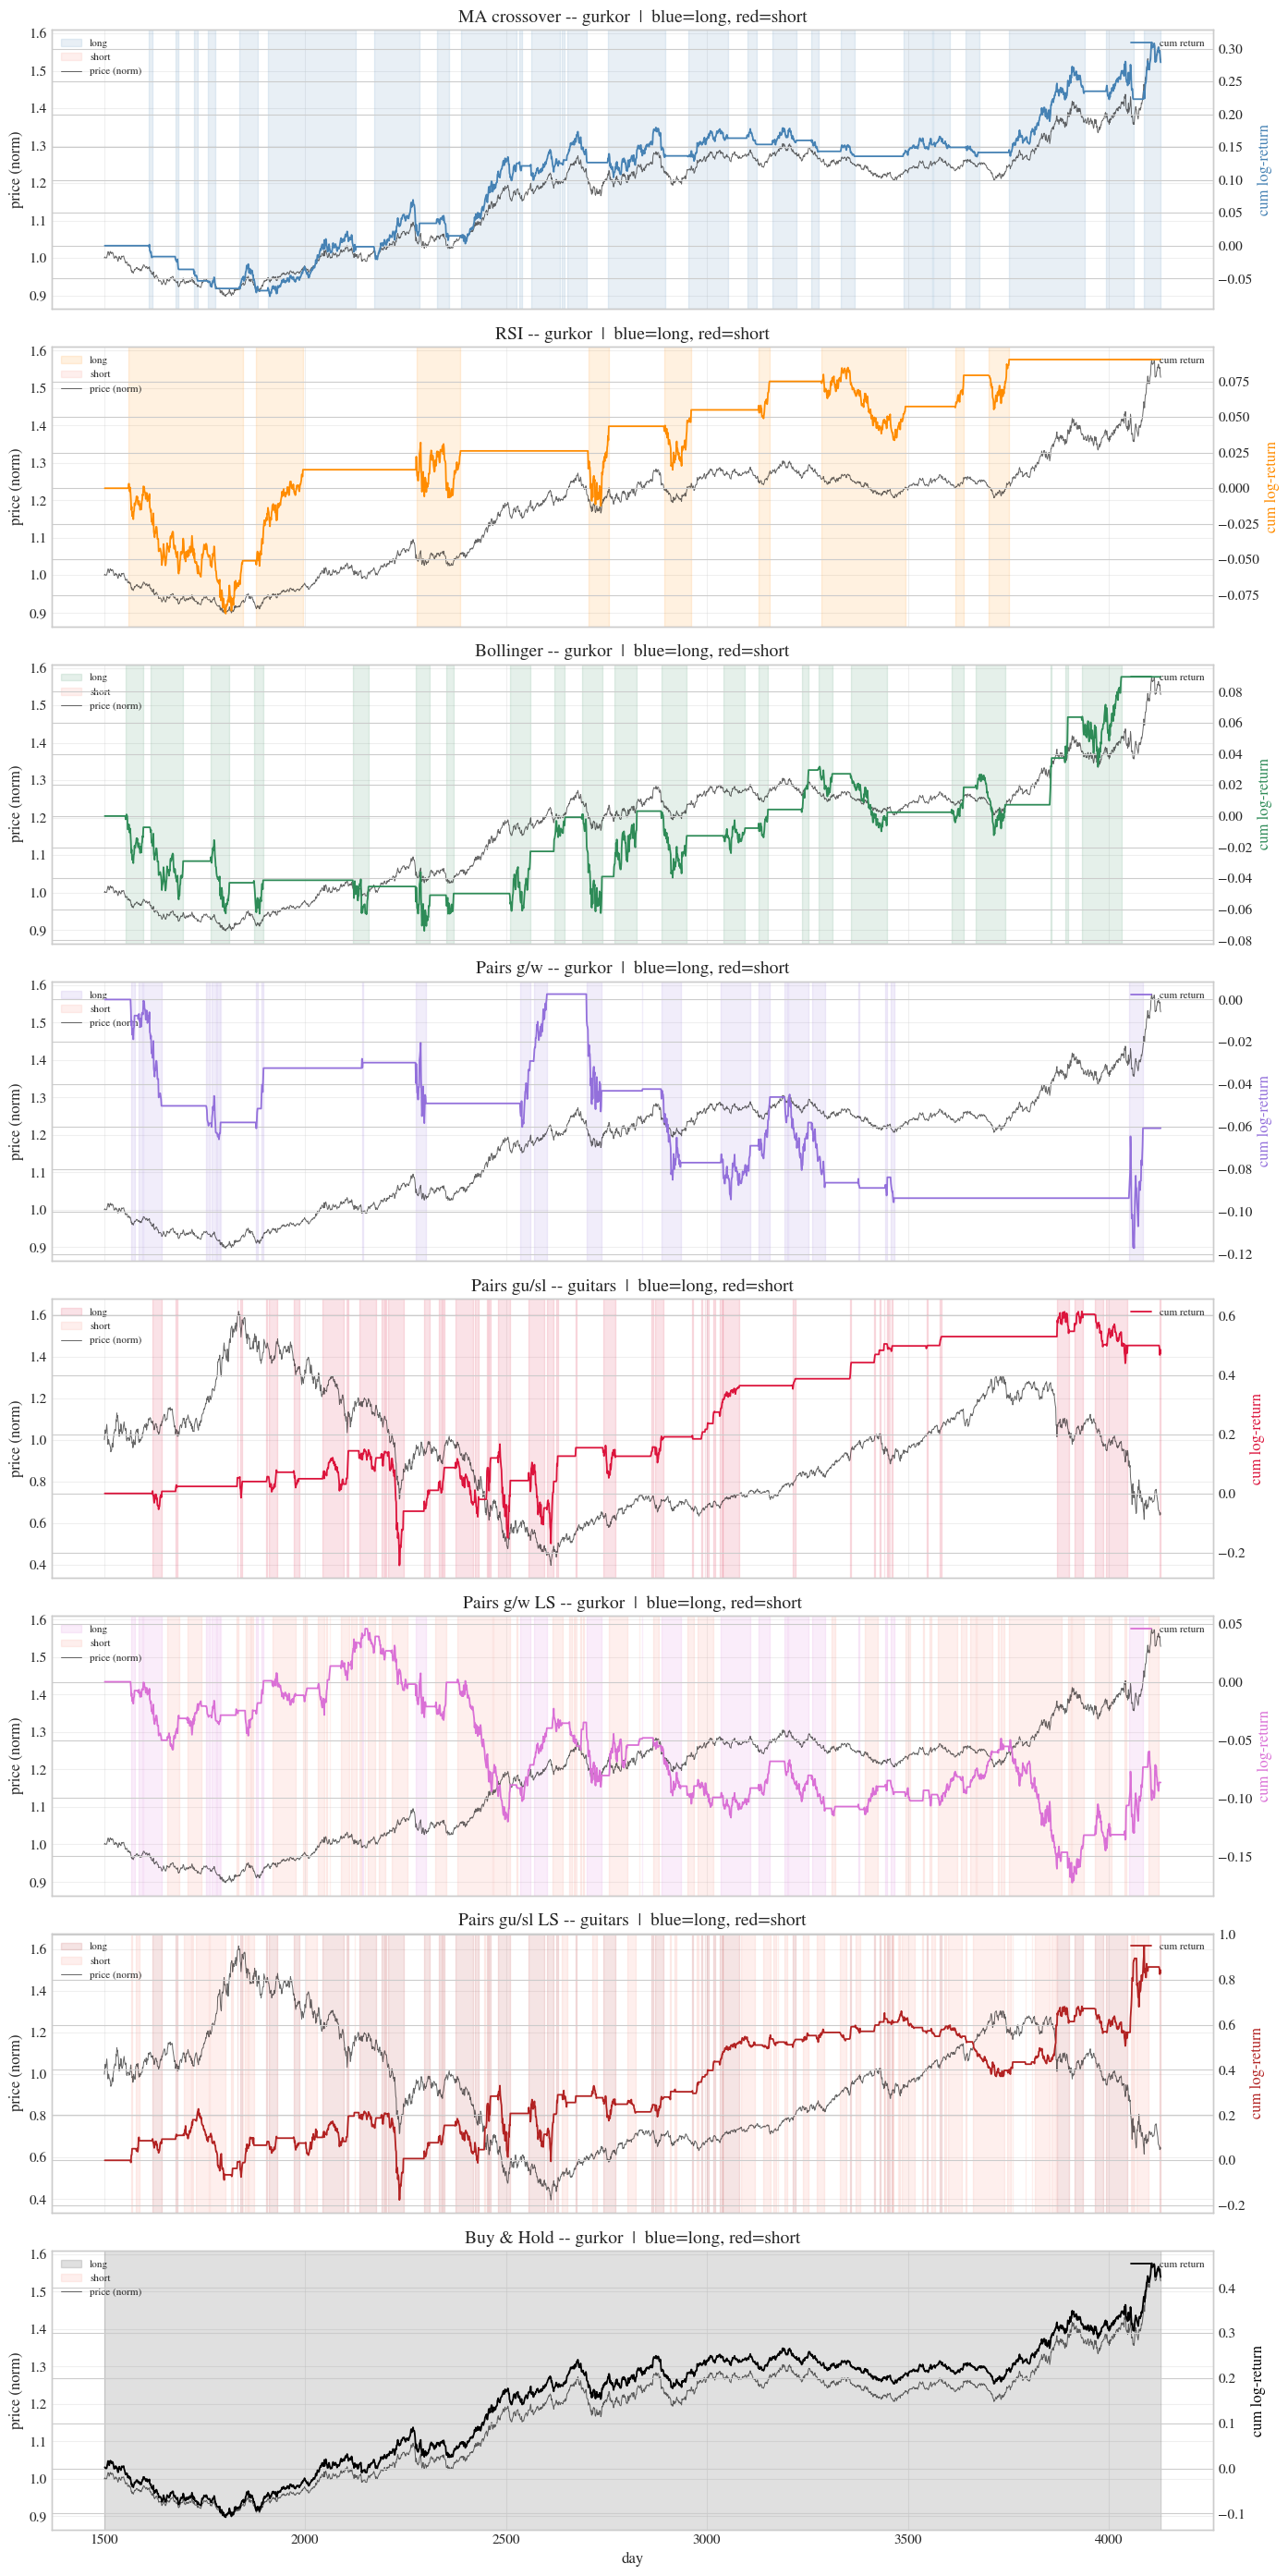

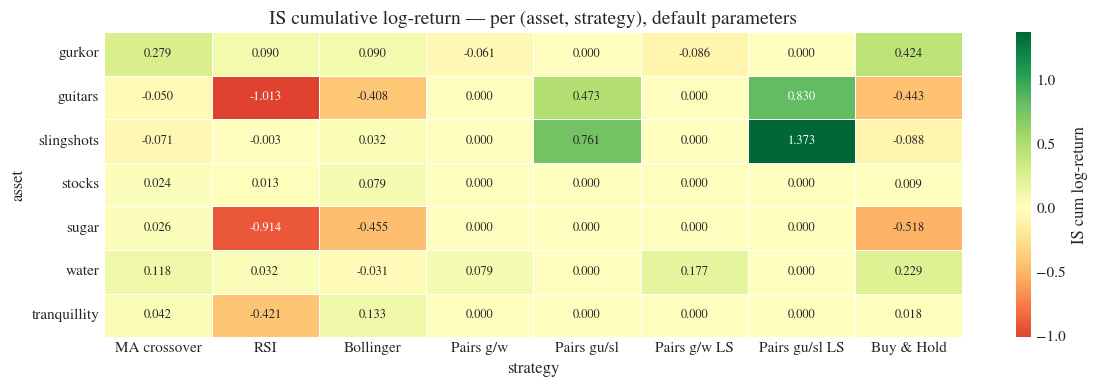

In [9]:
FAST, SLOW          = 20, 60
RSI_WINDOW          = 14; RSI_OVERSOLD = 30.0; RSI_OVERBOUGHT = 70.0
BB_WINDOW           = 20; BB_NSTD      = 2.0
PAIRS_WINDOW        = 60; PAIRS_ENTRY_Z = 1.5; PAIRS_EXIT_Z = 0.5

STRAT_COLORS = {
    "MA crossover":    "steelblue",
    "RSI":             "darkorange",
    "Bollinger":       "seagreen",
    "Pairs g/w":       "mediumpurple",
    "Pairs gu/sl":     "crimson",
    "Pairs g/w LS":    "orchid",
    "Pairs gu/sl LS":  "firebrick",
    "Buy & Hold":      "black",
}

res_ma_def      = apply_signal(ma_crossover_signal(prices_is, fast=FAST, slow=SLOW), prices_is)
res_rsi_def     = apply_signal(rsi_signal(prices_is, window=RSI_WINDOW,
                               oversold=RSI_OVERSOLD, overbought=RSI_OVERBOUGHT), prices_is)
res_bb_def      = apply_signal(bollinger_signal(prices_is, window=BB_WINDOW, n_std=BB_NSTD), prices_is)
res_gw_def      = apply_signal(gw_signal(prices_is,
                               window=PAIRS_WINDOW, entry_z=PAIRS_ENTRY_Z, exit_z=PAIRS_EXIT_Z), prices_is)
res_gusl_def    = apply_signal(gusl_signal(prices_is,
                               window=PAIRS_WINDOW, entry_z=PAIRS_ENTRY_Z, exit_z=PAIRS_EXIT_Z), prices_is)
res_gw_ls_def   = apply_signal(gw_ls_signal(prices_is,
                               window=PAIRS_WINDOW, entry_z=PAIRS_ENTRY_Z, exit_z=PAIRS_EXIT_Z), prices_is)
res_gusl_ls_def = apply_signal(gusl_ls_signal(prices_is,
                               window=PAIRS_WINDOW, entry_z=PAIRS_ENTRY_Z, exit_z=PAIRS_EXIT_Z), prices_is)
res_bh_def      = apply_signal(buy_and_hold_signal(prices_is), prices_is)

default_specs = [
    ("MA crossover",   res_ma_def,      "steelblue"),
    ("RSI",            res_rsi_def,     "darkorange"),
    ("Bollinger",      res_bb_def,      "seagreen"),
    ("Pairs g/w",      res_gw_def,      "mediumpurple"),
    ("Pairs gu/sl",    res_gusl_def,    "crimson"),
    ("Pairs g/w LS",   res_gw_ls_def,   "orchid"),
    ("Pairs gu/sl LS", res_gusl_ls_def, "firebrick"),
    ("Buy & Hold",     res_bh_def,      "black"),
]

# Show gurkor for all strategies (pairs g/w: gurkor leg; pairs gu/sl: guitars leg)
asset = "gurkor"
col_map = {
    "Pairs gu/sl":    "guitars",
    "Pairs gu/sl LS": "guitars",
}
n_strats = len(default_specs)
fig, axes = plt.subplots(n_strats, 1, figsize=(14, 3.5 * n_strats), sharex=True)
for ax, (label, res, c) in zip(axes, default_specs):
    col = col_map.get(label, asset)
    sig        = res["signals"][col]
    cum        = res["cumulative"][col]
    price_norm = prices_is[col] / prices_is[col].iloc[0]
    ax.fill_between(sig.index, 0, 1, where=(sig > 0), alpha=0.12, color=c,
                    transform=ax.get_xaxis_transform(), label="long")
    ax.fill_between(sig.index, 0, 1, where=(sig < 0), alpha=0.12, color="salmon",
                    transform=ax.get_xaxis_transform(), label="short")
    ax.plot(prices_is.index, price_norm, color="black", linewidth=0.7, alpha=0.6, label="price (norm)")
    ax2 = ax.twinx()
    ax2.plot(cum.index, cum.values, color=c, linewidth=1.3, label="cum return")
    ax.set_title(f"{label} -- {col}  |  blue=long, red=short")
    ax.set_ylabel("price (norm)"); ax2.set_ylabel("cum log-return", color=c)
    ax.legend(loc="upper left", fontsize=8); ax2.legend(loc="upper right", fontsize=8)
    ax.grid(True, alpha=0.3)
axes[-1].set_xlabel("day")
plt.tight_layout()
plt.savefig(output / "is_default_signals.png", bbox_inches="tight")
plt.show()

# per (asset, strategy) IS cumulative log-return — default params
cum_ret = {}
for label, res, _ in default_specs:
    cum_ret[label] = {col: res["cumulative"][col].iloc[-1] for col in prices_is.columns}
cum_df = pd.DataFrame(cum_ret)

fig, ax = plt.subplots(figsize=(12, 4))
annot  = cum_df.apply(lambda col: col.map(lambda x: f"{x:.3f}" if not pd.isna(x) else ""))
sns.heatmap(cum_df, annot=annot, fmt="", cmap="RdYlGn", center=0,
            linewidths=0.5, ax=ax, cbar_kws={"label": "IS cum log-return"},
            annot_kws={"size": 9})
ax.set_title("IS cumulative log-return — per (asset, strategy), default parameters")
ax.set_xlabel("strategy"); ax.set_ylabel("asset")
plt.tight_layout()
plt.savefig(output / "is_default_per_asset.png", bbox_inches="tight")
plt.show()


## 5. Parameter Tuning via Grid Search

### Why parameters matter

Each strategy has free parameters -- window lengths, threshold values -- that control how aggressively it trades. The right values are market-regime dependent: too-short windows produce noisy signals; too-long windows respond too slowly.

### Grid search on IS data

We evaluate every combination in a predefined grid by computing the **IS Sharpe ratio**. Two optimisation scopes are used depending on the strategy:

**Per-asset optimisation (MA crossover, RSI, Bollinger):** each asset's parameters are selected independently by maximising that asset's own IS Sharpe ratio. This allows the strategy to adapt to each asset's individual dynamics but increases the number of free parameters -- 7 independent selections from the same grid instead of one -- and therefore also increases the risk of overfitting.

**Portfolio-level optimisation (Pairs strategies):** a single shared parameter set is selected by maximising the equal-weight portfolio Sharpe across both legs of the pair. Per-asset splitting is not applicable here since the pair trades two specific assets together.

| Strategy | Optimisation scope | Parameters searched |
|----------|-------------------|-------------------|
| MA crossover | Per asset | `fast` in {2,5,10,15,20,30}, `slow` in {20,30,40,60,80,120,150,200,252} |
| RSI | Per asset | `window` in {2,7,14,21,50}, `oversold` in {2,5,10,20,25,30,50,100}, `overbought` in {70,75,80,100} |
| Bollinger | Per asset | `window` in {2,5,10,15,20,30,40}, `n_std` in {0.5,1.0,1.5,2.0,2.5,3.0} |
| Pairs g/w | Portfolio | `window` in {2,5,10,30,60}, `entry_z` in {0.25,0.5,1.0,1.5,2.0} |
| Pairs gu/sl | Portfolio | same as above |

In [10]:
def grid_search(
    prices_ref: pd.DataFrame,
    signal_fn,
    param_grid: list[dict],
    ann: int = 365,
) -> pd.DataFrame:
    """Strategy-agnostic IS grid search. Optimises equal-weight portfolio Sharpe."""
    rows = []
    for params in param_grid:
        sig  = signal_fn(prices_ref, **params)
        res  = apply_signal(sig, prices_ref)
        port = res["returns"].mean(axis=1).dropna()
        vol  = port.std() * np.sqrt(ann)
        sr   = port.mean() * ann / vol if vol > 0 else np.nan
        rows.append({**params, "sharpe": sr})
    return pd.DataFrame(rows)


def per_asset_grid_search(
    prices_ref: pd.DataFrame,
    signal_fn,
    param_grid: list[dict],
    ann: int = 365,
) -> dict[str, dict]:
    """
    Grid search optimised independently per asset.

    Each asset's parameters maximise that asset's own IS Sharpe ratio.
    Returns {asset_name: best_params_dict}.
    """
    log_ret        = np.log(prices_ref).diff()
    best_per_asset = {}
    for asset in prices_ref.columns:
        rows = []
        for params in param_grid:
            sig = signal_fn(prices_ref, **params)[asset]
            ret = (sig * log_ret[asset]).dropna()
            vol = ret.std() * np.sqrt(ann)
            sr  = ret.mean() * ann / vol if vol > 0 else np.nan
            rows.append({**params, "sharpe": sr})
        orig_types = {k: type(v) for k, v in param_grid[0].items()}
        df   = pd.DataFrame(rows)
        best = df.loc[df["sharpe"].idxmax()] if df["sharpe"].notna().any() else df.iloc[0]
        best_per_asset[asset] = {k: orig_types[k](v) for k, v in best.items() if k != "sharpe"}
    return best_per_asset


def build_per_asset_signal(
    prices: pd.DataFrame,
    signal_fn,
    best_params: dict[str, dict],
) -> pd.DataFrame:
    """Assemble a signal DataFrame using each asset's own best parameters."""
    return pd.DataFrame({
        asset: signal_fn(prices, **params)[asset]
        for asset, params in best_params.items()
    })

Running per-asset IS grid searches (MA, RSI, Bollinger)...
Running portfolio-level IS grid searches (Pairs)...

Per-asset IS-optimal parameters:


,MA fast,MA slow,RSI window,RSI oversold,RSI overbought,BB window,BB n_std
asset,,,,,,,
gurkor,10,30,2,30.0,70.0,30,2.5
guitars,20,200,50,30.0,50.0,10,1.5
slingshots,10,40,2,20.0,80.0,2,0.5
stocks,10,120,2,2.0,75.0,5,1.0
sugar,10,150,2,10.0,70.0,5,1.0
water,15,30,14,30.0,80.0,2,0.5
tranquillity,30,120,21,20.0,75.0,20,2.5



Pairs g/w   (portfolio-level): {'window': 2, 'entry_z': 0.25, 'exit_z': 0.5}  (IS Sharpe=1.846)
Pairs gu/sl (portfolio-level): {'window': 5, 'entry_z': 0.25, 'exit_z': 0.5}  (IS Sharpe=1.928)


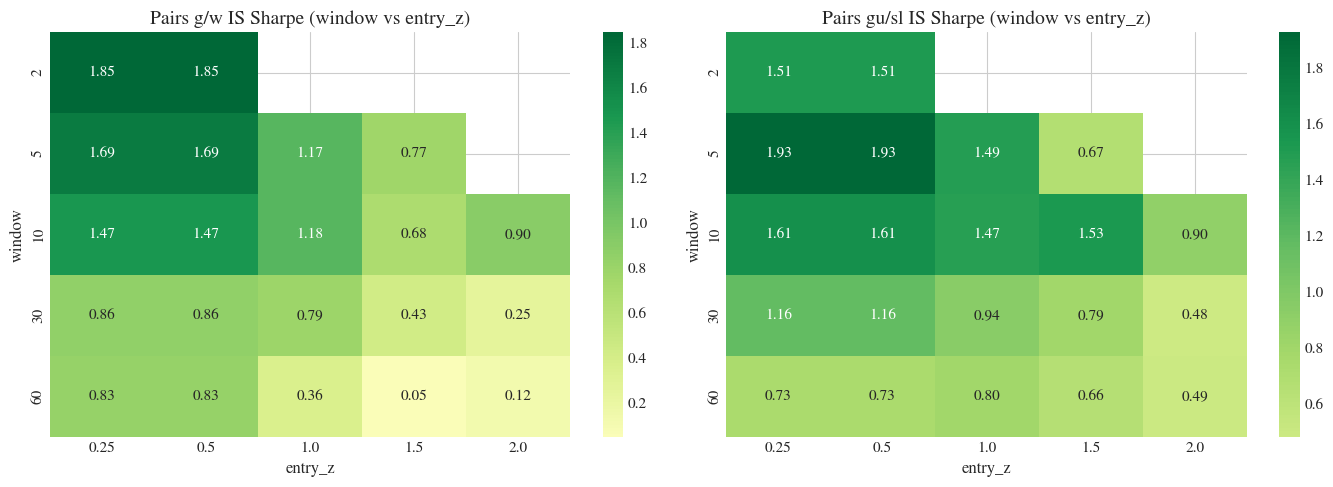

In [11]:
FAST_GRID = [10, 15, 20, 30]
SLOW_GRID = [20, 30, 40, 60, 80, 120,150,200,252]
MA_PARAM_GRID  = [{"fast": f, "slow": s} for f in FAST_GRID for s in SLOW_GRID if f < s]
RSI_PARAM_GRID = [
    {"window": w, "oversold": float(os), "overbought": float(ob)}
    for w in [2,7, 14, 21,50] for os in [2,5,10,20, 25, 30,50,100] for ob in [50,70, 75, 80,100]
]
BB_PARAM_GRID = [
    {"window": w, "n_std": n}
    for w in [2,5,10, 15, 20, 30, 40] for n in [0.5,1,1.5, 2.0, 2.5, 3.0]
]
PAIRS_PARAM_GRID = [
    {"window": w, "entry_z": e, "exit_z": 0.5}
    for w in [2,5,10,30, 60]
    for e in [0.25,0.5,1.0, 1.5, 2.0]
]

# MA, RSI, Bollinger: each asset gets its own best parameters
print("Running per-asset IS grid searches (MA, RSI, Bollinger)...")
best_ma_per_asset  = per_asset_grid_search(prices_is, ma_crossover_signal, MA_PARAM_GRID)
best_rsi_per_asset = per_asset_grid_search(prices_is, rsi_signal,          RSI_PARAM_GRID)
best_bb_per_asset  = per_asset_grid_search(prices_is, bollinger_signal,    BB_PARAM_GRID)

# Pairs: portfolio-level tuning (the pair is fixed; per-asset split does not apply)
print("Running portfolio-level IS grid searches (Pairs)...")
grid_gw_is   = grid_search(prices_is, gw_signal,   PAIRS_PARAM_GRID)
grid_gusl_is = grid_search(prices_is, gusl_signal, PAIRS_PARAM_GRID)

best_gw      = grid_gw_is.loc[grid_gw_is["sharpe"].idxmax()]
best_gusl    = grid_gusl_is.loc[grid_gusl_is["sharpe"].idxmax()]
BEST_GW_PARAMS   = {"window": int(best_gw["window"]),
                    "entry_z": float(best_gw["entry_z"]),
                    "exit_z":  float(best_gw["exit_z"])}
BEST_GUSL_PARAMS = {"window": int(best_gusl["window"]),
                    "entry_z": float(best_gusl["entry_z"]),
                    "exit_z":  float(best_gusl["exit_z"])}

# Per-asset best parameter summary table
summary_rows = []
for asset in prices_is.columns:
    ma  = best_ma_per_asset[asset]
    rsi = best_rsi_per_asset[asset]
    bb  = best_bb_per_asset[asset]
    summary_rows.append({
        "asset":           asset,
        "MA fast":         int(ma["fast"]),
        "MA slow":         int(ma["slow"]),
        "RSI window":      int(rsi["window"]),
        "RSI oversold":    float(rsi["oversold"]),
        "RSI overbought":  float(rsi["overbought"]),
        "BB window":       int(bb["window"]),
        "BB n_std":        float(bb["n_std"]),
    })
print("\nPer-asset IS-optimal parameters:")
display(pd.DataFrame(summary_rows).set_index("asset"))

print(f"\nPairs g/w   (portfolio-level): {BEST_GW_PARAMS}  (IS Sharpe={best_gw['sharpe']:.3f})")
print(f"Pairs gu/sl (portfolio-level): {BEST_GUSL_PARAMS}  (IS Sharpe={best_gusl['sharpe']:.3f})")

# Pairs heatmaps
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(grid_gw_is.pivot(index="window", columns="entry_z", values="sharpe"),
            annot=True, fmt=".2f", cmap="RdYlGn", center=0, ax=axes[0])
axes[0].set_title("Pairs g/w IS Sharpe (window vs entry_z)")
sns.heatmap(grid_gusl_is.pivot(index="window", columns="entry_z", values="sharpe"),
            annot=True, fmt=".2f", cmap="RdYlGn", center=0, ax=axes[1])
axes[1].set_title("Pairs gu/sl IS Sharpe (window vs entry_z)")
plt.tight_layout()
plt.savefig(output / "grid_search_heatmaps.png", bbox_inches="tight")
plt.show()

## 6. Overfitting and Why OoS Data Matters

### What is overfitting?

Overfitting occurs when a model learns the specific patterns of the training data so well that it fails to generalise to new data. In trading, the "model" is a set of parameter choices; the "training data" is the IS period.

**The core problem:** given enough parameters to search over, we can always find *some* combination that looks excellent on IS data -- not because it captures a genuine market inefficiency, but because it was selected specifically because it happened to work on that historical window.

Analogy: if you flip a coin 100 times, you can find a subsequence where heads appeared 80% of the time. Finding it does not mean the coin is biased -- you just searched until you found something that looked interesting.

### Why IS Sharpe is a biased estimate

Suppose you evaluate $K$ parameter combinations and pick the one with the highest IS Sharpe. Under the null hypothesis (all strategies are pure noise with true Sharpe = 0), the expected maximum Sharpe across $K$ trials satisfies:

$$E\!\left[\max_{k=1}^{K} S_k\right] \approx \sqrt{2 \log K}$$

With $K = 24$ combinations (MA grid), the expected maximum noise Sharpe is $\approx \sqrt{2\log 24} \approx 2.4$. With $K = 27$ (RSI), it is $\approx 2.5$. These are **purely from selection**, with zero true signal. The larger the grid, the more inflated the IS optimum becomes.

### Signs of overfitting to watch for

| Warning sign | Interpretation |
|-------------|---------------|
| IS Sharpe much greater than OoS Sharpe | Strong overfitting to IS window |
| Best params at edge of grid | Optimiser fitting noise; no interior optimum |
| Params change dramatically fold-to-fold | No stable relationship with market features |
| Performance driven by 1-2 assets or folds | Luck, not edge |

### Out-of-sample data as the antidote

The OoS window was never used in any decision. Because no parameters were chosen based on OoS data, OoS performance is an **unbiased estimate** of how the strategy would have performed if deployed at that date.

**The golden rule:** the OoS window must be used exactly once. If you examine OoS results and then adjust the strategy in response, it becomes a second IS window -- you are now fitting to it, and any further OoS test requires completely fresh data.


## 7. Evaluation Metrics

Before examining OoS results, we define exactly how performance is measured. Max drawdown is computed on actual equity (not cumulative log-return) to correctly represent the worst peak-to-trough loss.

| Metric | Definition | What it measures |
|--------|-----------|------------------|
| **Total log return** | Sum of log-returns | Total compounded gain |
| **Annualised return** | 365 * mean daily return | Average daily return scaled to one year |
| **Annualised volatility** | sqrt(365) * std(daily returns) | Risk |
| **Sharpe ratio** | ann. return / ann. vol. | Return per unit of total risk |
| **Sortino ratio** | ann. return / downside vol. | Return per unit of downside risk only |
| **Max drawdown** | min(equity / peak_equity - 1) | Worst peak-to-trough equity loss |
| **Calmar ratio** | ann. return / abs(max DD) | Return per unit of worst drawdown |
| **Hit rate** | fraction of days with positive return | How often the strategy earns anything |
| **Profit factor** | sum(wins) / abs(sum(losses)) | Gross profit vs gross loss; >1 = profitable overall |
| **Avg win / Avg loss** | mean(positive days) / abs(mean(negative days)) | Size of a typical win vs a typical loss |
| **Win/loss ratio** | avg_win / abs(avg_loss) | Reward-to-risk per trade |
| **Max consec. wins/losses** | longest run of positive / negative days | Streak risk — how long bad runs last |
| **Avg hold (days)** | days in position / number of entries | Average trade duration |
| **Trades per year** | entries per year = n_trades / (n_days / 365) | Trading frequency |
| **Win/loss ratio** | avg_win / |avg_loss| | Reward-to-risk per active day |
| **Max consec. wins/losses** | longest run of positive / negative days | Streak risk |


In [12]:
def backtest_metrics(strat_ret: pd.Series, bh_ret: pd.Series | None = None, ann: int = 365) -> dict:
    """
    Comprehensive single-series backtest metrics.
    Max drawdown uses actual equity exp(cumulative log-return), not raw log-return.
    """
    sr = strat_ret.dropna()
    if sr.empty:
        return {}

    cum          = sr.cumsum()
    ann_ret      = sr.mean() * ann
    ann_vol      = sr.std() * np.sqrt(ann)
    sharpe       = ann_ret / ann_vol if ann_vol > 0 else np.nan

    neg          = sr[sr < 0]
    downside_vol = neg.std() * np.sqrt(ann) if len(neg) > 1 else np.nan
    sortino      = ann_ret / downside_vol if (downside_vol and downside_vol > 0) else np.nan

    equity   = np.exp(cum)
    drawdown = equity / equity.cummax() - 1
    max_dd   = drawdown.min()
    calmar   = ann_ret / abs(max_dd) if max_dd < 0 else np.nan

    signal   = (sr != 0).astype(int)
    n_trades = int(((signal == 1) & (signal.shift(1) == 0)).sum())
    avg_hold = (signal.sum() / n_trades) if n_trades > 0 else np.nan
    n_days   = len(sr)
    trades_per_year = (n_trades / (n_days / ann)) if n_days > 0 and n_trades > 0 else np.nan

    wins   = sr[sr > 0]
    losses = sr[sr < 0]
    profit_factor  = (wins.sum() / abs(losses.sum())) if len(losses) > 0 and losses.sum() != 0 else np.nan
    avg_win        = float(wins.mean())   if len(wins)   > 0 else np.nan
    avg_loss       = float(losses.mean()) if len(losses) > 0 else np.nan
    win_loss_ratio = (avg_win / abs(avg_loss)) if (not np.isnan(avg_loss) and avg_loss != 0) else np.nan

    signs = np.sign(sr.values)
    def _max_streak(s, target):
        best = cur = 0
        for v in s:
            if v == target:
                cur += 1; best = max(best, cur)
            else:
                cur = 0
        return int(best)
    max_consec_wins   = _max_streak(signs,  1)
    max_consec_losses = _max_streak(signs, -1)

    out = {
        "total_log_ret":     round(cum.iloc[-1], 4),
        "ann_return":        round(ann_ret, 4),
        "ann_vol":           round(ann_vol, 4),
        "sharpe":            round(sharpe, 3),
        "sortino":           round(sortino, 3) if not np.isnan(sortino) else np.nan,
        "max_drawdown":      round(max_dd, 4),
        "calmar":            round(calmar, 3) if (calmar and not np.isnan(calmar)) else np.nan,
        "hit_rate":          round((sr > 0).mean(), 3),
        "profit_factor":     round(profit_factor, 3) if not np.isnan(profit_factor) else np.nan,
        "avg_win":           round(avg_win, 5) if not np.isnan(avg_win) else np.nan,
        "avg_loss":          round(avg_loss, 5) if not np.isnan(avg_loss) else np.nan,
        "win_loss_ratio":    round(win_loss_ratio, 3) if not np.isnan(win_loss_ratio) else np.nan,
        "max_consec_wins":   max_consec_wins,
        "max_consec_losses": max_consec_losses,
        "n_trades":          int(n_trades),
        "avg_hold_days":     round(avg_hold, 1) if avg_hold and not np.isnan(avg_hold) else np.nan,
        "trades_per_year":   round(trades_per_year, 1) if not np.isnan(trades_per_year) else np.nan,
    }
    if bh_ret is not None:
        bh        = bh_ret.dropna()
        bh_ann    = bh.mean() * ann
        bh_vol    = bh.std() * np.sqrt(ann)
        bh_sharpe = bh_ann / bh_vol if bh_vol > 0 else np.nan
        out["bh_ann_return"] = round(bh_ann, 4)
        out["bh_sharpe"]     = round(bh_sharpe, 3)
        out["excess_ret"]    = round(ann_ret - bh_ann, 4)
    return out


## 8. Walk-Forward Validation

All performance evaluation is done via **walk-forward pseudo-OoS**: parameters are selected on an expanding IS window, then tested on the immediately following sub-fold. The true OoS window is set aside and never examined.

| Sub-section | Question answered |
|-------------|-----------------|
| **8.1 Walk-forward** | Do strategies produce positive pseudo-OoS returns consistently across sub-folds? |
| **8.1.1 Parameter stability** | Do the chosen parameters change dramatically fold-to-fold? |
| **8.2 Bootstrap significance** | Is the walk-forward Sharpe statistically distinguishable from zero, after correcting for multiple testing across all (asset, strategy) pairs? |
| **8.3 Per-asset breakdown** | Does performance hold consistently across all assets, or is it driven by one lucky asset? |

### 8.1 Walk-Forward Validation

Walk-forward repeats IS parameter optimisation across 5 non-overlapping sub-folds of the full dataset using a **fixed-size sliding IS window**. Each training window has the same length (`train_size` days); the window slides forward by one fold at a time. Crucially, none of these folds use the main 70/30 OoS window — this is purely an IS robustness check.

```
[IS1] | OoS1
   [IS2] | OoS2     (same width, shifted forward)
      [IS3] | OoS3
         [IS4] | OoS4
            [IS5] | OoS5
```

**What to look for:**
- **OoS Sharpe consistency** -- positive in all folds, or driven by 1-2 lucky periods?
- **Parameter stability** -- do the best parameters change dramatically fold-to-fold? High instability suggests noise.
- **Stitched equity curve** -- the concatenated OoS returns across folds. A steadily rising curve indicates genuine positive expectation across time.


In [13]:
def walk_forward(
    prices: pd.DataFrame,
    signal_fn,
    param_grid: list[dict],
    n_folds: int = 5,
    train_size: int | None = None,
    ann: int = 365,
    per_asset: bool = False,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Sliding-window walk-forward. Re-optimises on each IS fold; tests on next OoS fold.

    train_size -- fixed number of days in each IS window. If None, defaults to fold_size * n_folds
                  (same total IS data as before, but capped rather than expanding).
    per_asset=True  -- each fold runs per_asset_grid_search; each asset gets its own params.
    per_asset=False -- each fold runs grid_search; one shared param set for all assets.
    """
    n, fold_size = len(prices), len(prices) // (n_folds + 1)
    if train_size is None:
        train_size = fold_size * n_folds
    oos_chunks, fold_rows = [], []

    for fold in range(1, n_folds + 1):
        is_end  = fold * fold_size
        oos_end = min((fold + 1) * fold_size, n)
        if oos_end <= is_end:
            continue
        is_start = max(0, is_end - train_size)
        p_is     = prices.iloc[is_start:is_end]
        p_oos    = prices.iloc[is_end:oos_end]
        combined = pd.concat([p_is, p_oos])

        if per_asset:
            best_p  = per_asset_grid_search(p_is, signal_fn, param_grid, ann=ann)
            sig     = build_per_asset_signal(combined, signal_fn, best_p)
            is_rets = apply_signal(
                build_per_asset_signal(p_is, signal_fn, best_p), p_is
            )["returns"]
            # mean of per-asset Sharpes (not portfolio average)
            per_sr = []
            for col in is_rets.columns:
                r = is_rets[col].dropna()
                if (r == 0).all(): continue
                v = r.std() * np.sqrt(ann)
                per_sr.append(r.mean() * ann / v if v > 0 else np.nan)
            is_sr = float(np.nanmean(per_sr)) if per_sr else np.nan
            fold_rows.append({
                "fold": fold, "IS days": len(p_is), "OoS days": len(p_oos),
                "OoS start": p_oos.index[0], "OoS end": p_oos.index[-1],
                "IS Sharpe": round(float(is_sr), 3),
            })
        else:
            orig_types = {k: type(v) for k, v in param_grid[0].items()}
            param_cols = list(orig_types.keys())
            g        = grid_search(p_is, signal_fn, param_grid, ann=ann)
            best_row = g.loc[g["sharpe"].idxmax()]
            best_p   = {k: orig_types[k](best_row[k]) for k in param_cols}
            sig      = signal_fn(combined, **best_p)
            fold_rows.append({
                "fold": fold, "IS days": len(p_is), "OoS days": len(p_oos),
                "OoS start": p_oos.index[0], "OoS end": p_oos.index[-1],
                "IS Sharpe": round(float(best_row["sharpe"]), 3),
                **{f"best {k}": best_p[k] for k in param_cols},
            })

        oos_chunks.append(apply_signal(sig, combined)["returns"].loc[p_oos.index])

    return pd.concat(oos_chunks), pd.DataFrame(fold_rows)

WF_FOLDS = 20
print("Running walk-forward for all seven strategies...")
wf_returns,     wf_summary     = walk_forward(prices_is, ma_crossover_signal, MA_PARAM_GRID,    n_folds=WF_FOLDS, per_asset=True)
wf_ret_rsi,     wf_sum_rsi     = walk_forward(prices_is, rsi_signal,          RSI_PARAM_GRID,   n_folds=WF_FOLDS, per_asset=True)
wf_ret_bb,      wf_sum_bb      = walk_forward(prices_is, bollinger_signal,    BB_PARAM_GRID,    n_folds=WF_FOLDS, per_asset=True)
wf_ret_gw,      wf_sum_gw      = walk_forward(prices_is, gw_signal,           PAIRS_PARAM_GRID, n_folds=WF_FOLDS, per_asset=False)
wf_ret_gusl,    wf_sum_gusl    = walk_forward(prices_is, gusl_signal,         PAIRS_PARAM_GRID, n_folds=WF_FOLDS, per_asset=False)
wf_ret_gw_ls,   wf_sum_gw_ls   = walk_forward(prices_is, gw_ls_signal,        PAIRS_PARAM_GRID, n_folds=WF_FOLDS, per_asset=False)
wf_ret_gusl_ls, wf_sum_gusl_ls = walk_forward(prices_is, gusl_ls_signal,      PAIRS_PARAM_GRID, n_folds=WF_FOLDS, per_asset=False)
wf_ret_bh,      wf_sum_bh      = walk_forward(prices_is, buy_and_hold_signal, [{}],             n_folds=WF_FOLDS, per_asset=False)
print("Done.")

wf_specs = [
    ("MA crossover",   wf_returns,     wf_summary),
    ("RSI",            wf_ret_rsi,     wf_sum_rsi),
    ("Bollinger",      wf_ret_bb,      wf_sum_bb),
    ("Pairs g/w",      wf_ret_gw,      wf_sum_gw),
    ("Pairs gu/sl",    wf_ret_gusl,    wf_sum_gusl),
    ("Pairs g/w LS",   wf_ret_gw_ls,   wf_sum_gw_ls),
    ("Pairs gu/sl LS", wf_ret_gusl_ls, wf_sum_gusl_ls),
    ("Buy & Hold",     wf_ret_bh,      wf_sum_bh),
]

Running walk-forward for all seven strategies...
Done.


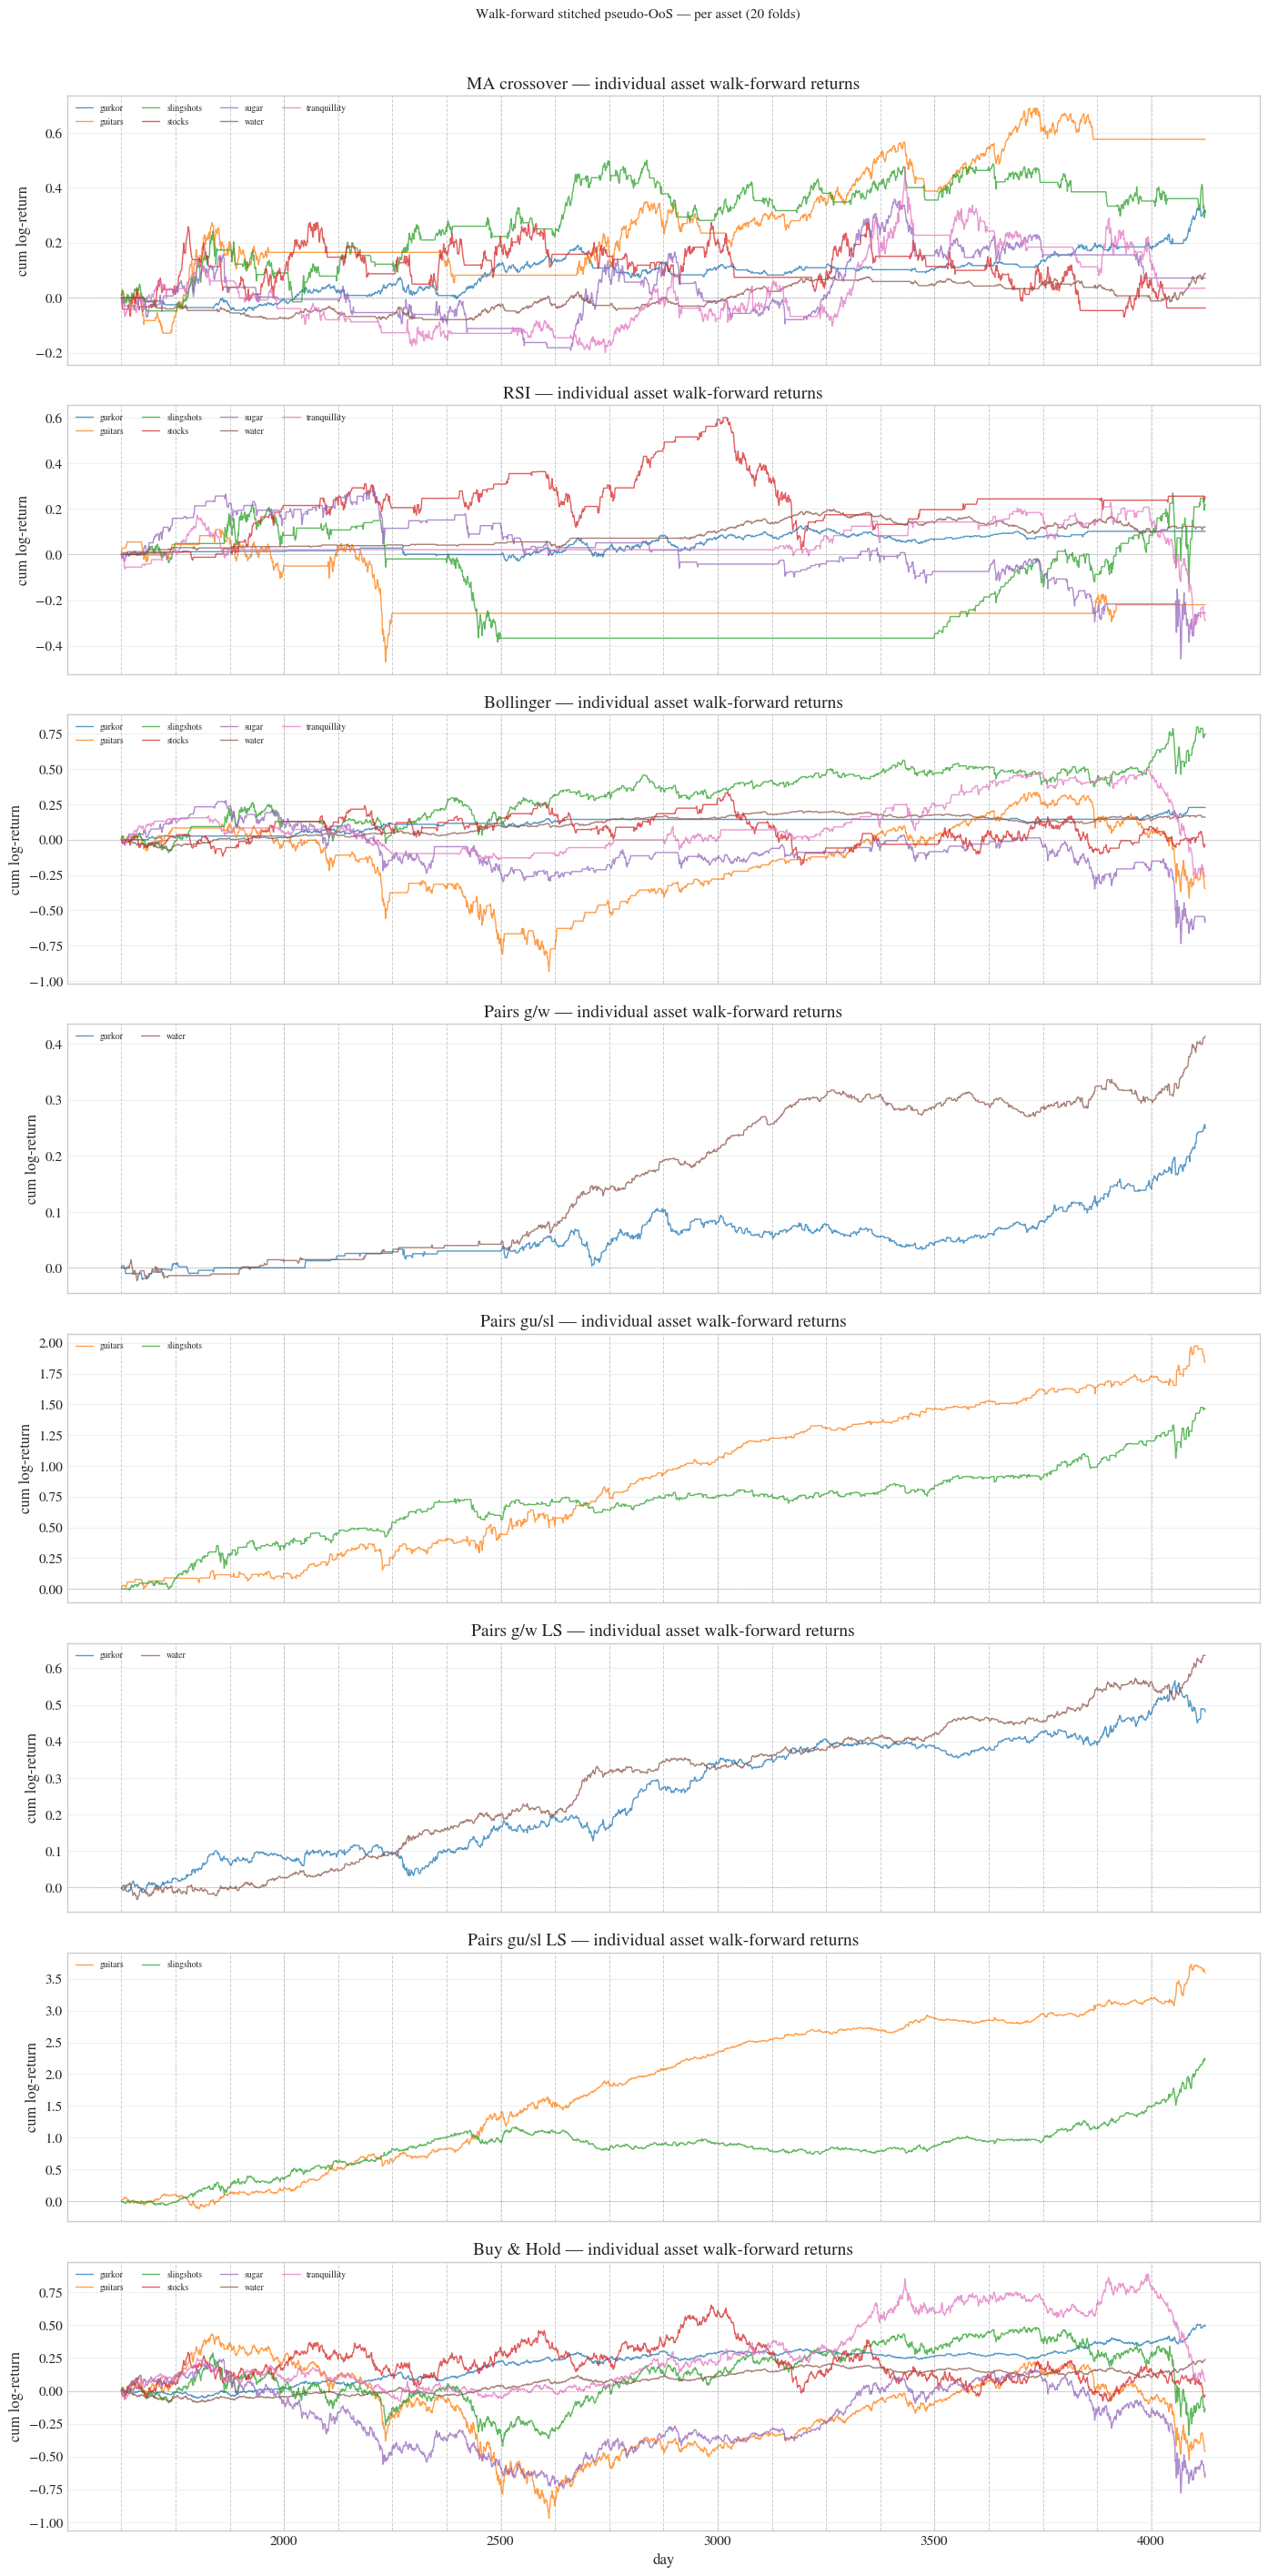

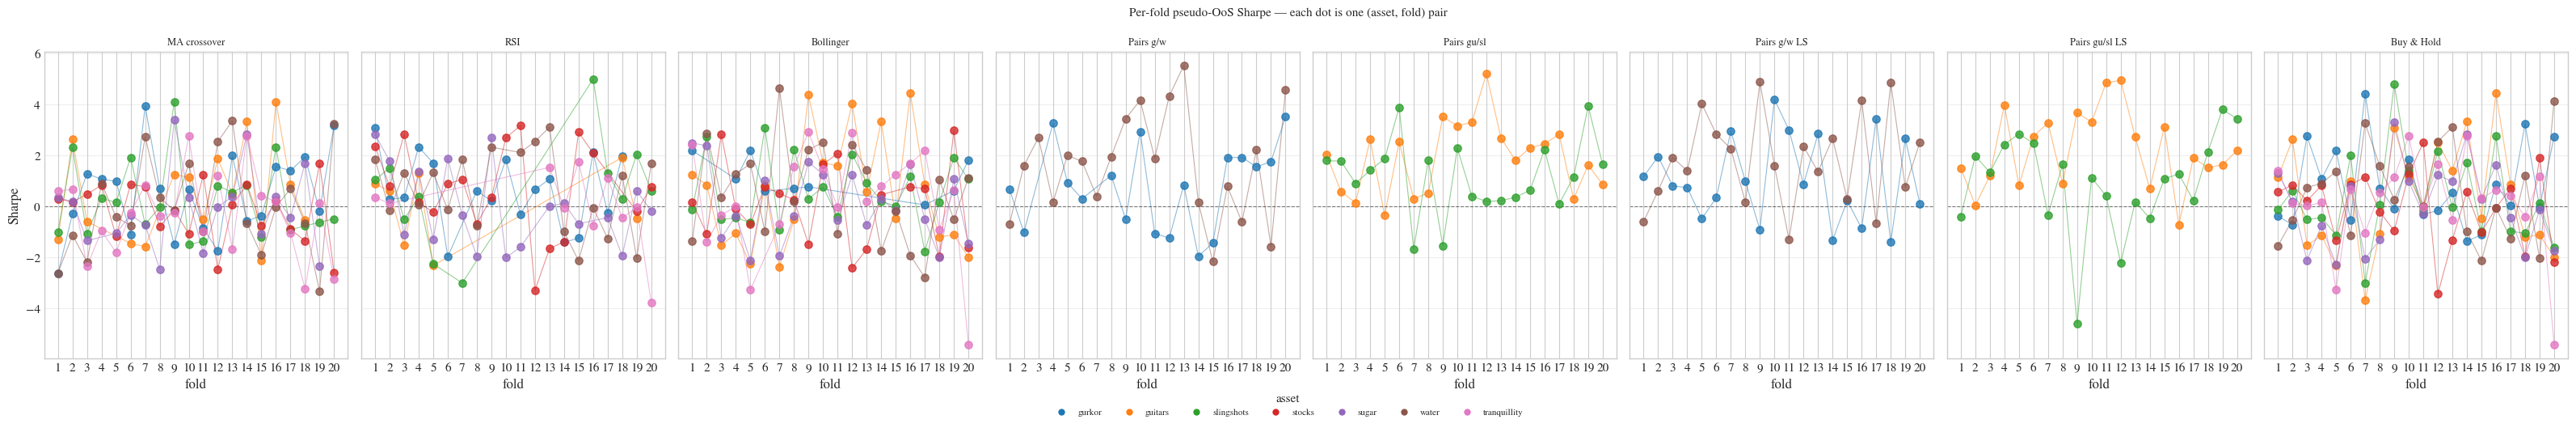

In [14]:
# ── per-strategy equity curves, one line per asset ───────────────────────────
n_strats  = len(wf_specs)
fig, axes = plt.subplots(n_strats, 1, figsize=(14, 3.5 * n_strats), sharex=True)

for ax, (label, wf_ret, wf_sum) in zip(axes, wf_specs):
    for col in wf_ret.columns:
        ret = wf_ret[col]
        if (ret == 0).all():          # never traded — skip
            continue
        cum = ret.cumsum()
        ax.plot(cum.index, cum.values, linewidth=1.0, alpha=0.75,
                color=asset_colors.get(col, "gray"), label=col)
    for _, row in wf_sum.iterrows():
        ax.axvline(row["OoS start"], color="gray", linewidth=0.7,
                   linestyle="--", alpha=0.4)
    ax.axhline(0, color="black", linewidth=0.5, linestyle=":", alpha=0.5)
    ax.set_title(f"{label} — individual asset walk-forward returns")
    ax.set_ylabel("cum log-return")
    ax.legend(fontsize=7, ncol=4, loc="upper left")
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("day")
plt.suptitle(f"Walk-forward stitched pseudo-OoS — per asset ({WF_FOLDS} folds)",
             fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig(output / "walk_forward.png", bbox_inches="tight")
plt.show()

# ── per-fold Sharpe: one dot per (asset, fold) ────────────────────────────────
fig, axes = plt.subplots(1, n_strats, figsize=(4 * n_strats, 5), sharey=True)

for ax, (label, wf_ret, wf_sum) in zip(axes, wf_specs):
    for col in wf_ret.columns:
        fold_xs, fold_srs = [], []
        for fold_i, (_, row) in enumerate(wf_sum.iterrows()):
            fold_ret = wf_ret[col].loc[row["OoS start"]:row["OoS end"]].dropna()
            if (fold_ret == 0).all():
                continue
            v  = fold_ret.std() * np.sqrt(365)
            sr = fold_ret.mean() * 365 / v if v > 0 else np.nan
            fold_xs.append(fold_i + 1)
            fold_srs.append(sr)
        if not fold_xs:
            continue
        color = asset_colors.get(col, "gray")
        ax.plot(fold_xs, fold_srs, color=color, linewidth=0.8, alpha=0.5, zorder=2)
        ax.scatter(fold_xs, fold_srs, color=color, s=45, alpha=0.8, zorder=3)
    ax.axhline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.5)
    ax.set_title(label, fontsize=9)
    ax.set_xlabel("fold")
    ax.set_xticks(range(1, WF_FOLDS + 1))
    ax.grid(True, alpha=0.3, axis="y")

axes[0].set_ylabel("Sharpe")

# shared legend for assets
handles = [plt.Line2D([0], [0], marker="o", color="w",
           markerfacecolor=asset_colors.get(col, "gray"), markersize=7, label=col)
           for col in prices_is.columns]
fig.legend(handles=handles, title="asset", fontsize=8,
           loc="lower center", ncol=7, bbox_to_anchor=(0.5, -0.05))
plt.suptitle("Per-fold pseudo-OoS Sharpe — each dot is one (asset, fold) pair",
             fontsize=11)
plt.tight_layout()
plt.savefig(output / "walk_forward_fold_sharpe.png", bbox_inches="tight")
plt.show()


### 8.1.1 Parameter Stability Across Folds

One of the key overfitting warning signs listed in Section 6 is: *"parameters change dramatically fold-to-fold."* The walk-forward above shows **whether** the strategy works across folds; this section shows **which parameters were chosen** on each expanding IS window.

**Interpretation guide:**
| Pattern | Verdict |
|---------|---------|
| Same parameter value across all folds | Stable — the optimiser found a robust setting |
| Gradual drift as IS window grows | Mild instability — may reflect genuine regime shift |
| Random jumps across the full grid range | Red flag — fitting noise, not a market relationship |

For per-asset strategies (MA, RSI, Bollinger), each cell shows the parameter chosen for that asset on that fold's IS window. High cross-asset agreement also indicates a genuine signal (all assets respond to the same parameter range).

In [15]:
def collect_fold_params(
    prices: pd.DataFrame,
    signal_fn,
    param_grid: list[dict],
    n_folds: int = WF_FOLDS,
    per_asset: bool = False,
) -> pd.DataFrame:
    """
    Re-run IS grid search on each expanding fold window and record the chosen parameters.
    per_asset=True  -> rows keyed by (fold, asset)
    per_asset=False -> rows keyed by fold
    """
    n, fold_size = len(prices), len(prices) // (n_folds + 1)
    records = []
    for fold in range(1, n_folds + 1):
        is_end = fold * fold_size
        p_is   = prices.iloc[:is_end]
        if per_asset:
            best_p = per_asset_grid_search(p_is, signal_fn, param_grid)
            for asset, params in best_p.items():
                records.append({"fold": fold, "asset": asset, **params})
        else:
            orig_types = {k: type(v) for k, v in param_grid[0].items()}
            g        = grid_search(p_is, signal_fn, param_grid)
            best_row = g.loc[g["sharpe"].idxmax()]
            best_p   = {k: orig_types[k](best_row[k]) for k in orig_types}
            records.append({"fold": fold, **best_p})
    return pd.DataFrame(records)


print("Collecting per-fold IS-optimal parameters (this reuses the grid search infrastructure)...")
fold_ma   = collect_fold_params(prices_is, ma_crossover_signal, MA_PARAM_GRID,   per_asset=True)
fold_rsi  = collect_fold_params(prices_is, rsi_signal,          RSI_PARAM_GRID,  per_asset=True)
fold_bb   = collect_fold_params(prices_is, bollinger_signal,    BB_PARAM_GRID,   per_asset=True)
fold_gw   = collect_fold_params(prices_is, gw_signal,           PAIRS_PARAM_GRID, per_asset=False)
fold_gusl = collect_fold_params(prices_is, gusl_signal,         PAIRS_PARAM_GRID, per_asset=False)
print("Done.")

# Summary: coefficient of variation across folds to flag instability
print("\nParameter range across folds (max - min) — larger = less stable:")
for name, df, params in [
    ("MA crossover", fold_ma,  ["fast", "slow"]),
    ("RSI",          fold_rsi, ["window", "oversold", "overbought"]),
    ("Bollinger",    fold_bb,  ["window", "n_std"]),
]:
    ranges = df.groupby("asset")[params].agg(lambda x: x.max() - x.min())
    print(f"\n{name}:")
    display(ranges)

Done.

Parameter range across folds (max - min) — larger = less stable:

MA crossover:


,fast,slow
asset,,
guitars,15,160
gurkor,20,222
slingshots,10,40
stocks,20,100
sugar,20,160
tranquillity,20,100
water,20,130



RSI:


,window,oversold,overbought
asset,,,
guitars,48,45.0,30.0
gurkor,19,98.0,30.0
slingshots,12,28.0,30.0
stocks,19,48.0,25.0
sugar,19,48.0,50.0
tranquillity,48,25.0,25.0
water,12,25.0,30.0



Bollinger:


,window,n_std
asset,,
guitars,30,1.5
gurkor,20,0.0
slingshots,38,2.5
stocks,38,2.5
sugar,35,2.0
tranquillity,35,2.5
water,38,2.0


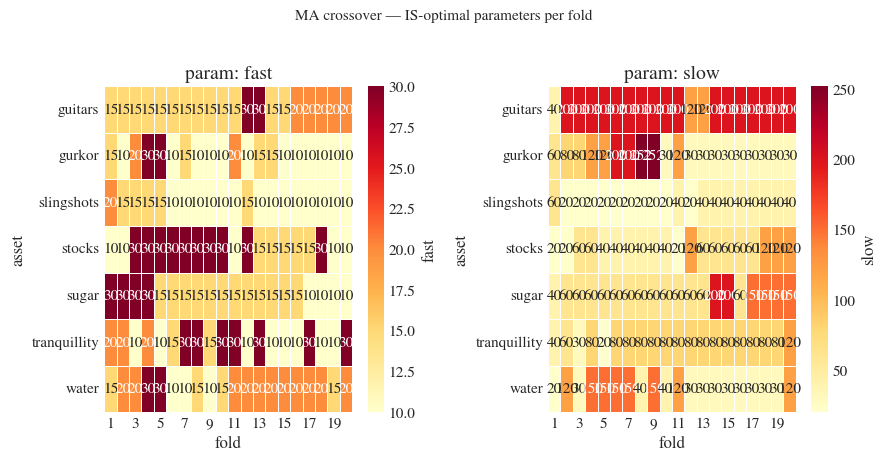

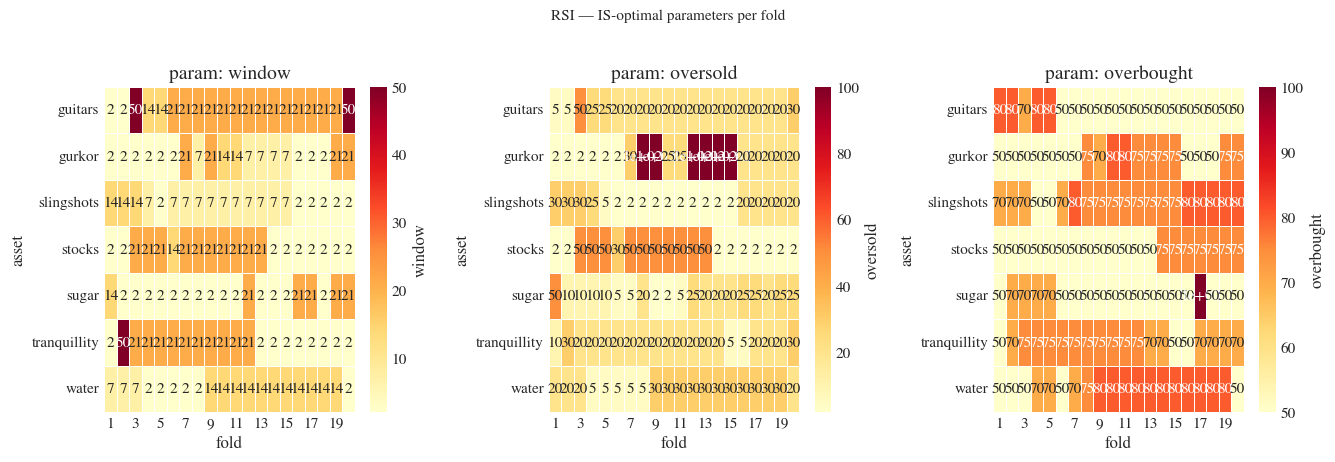

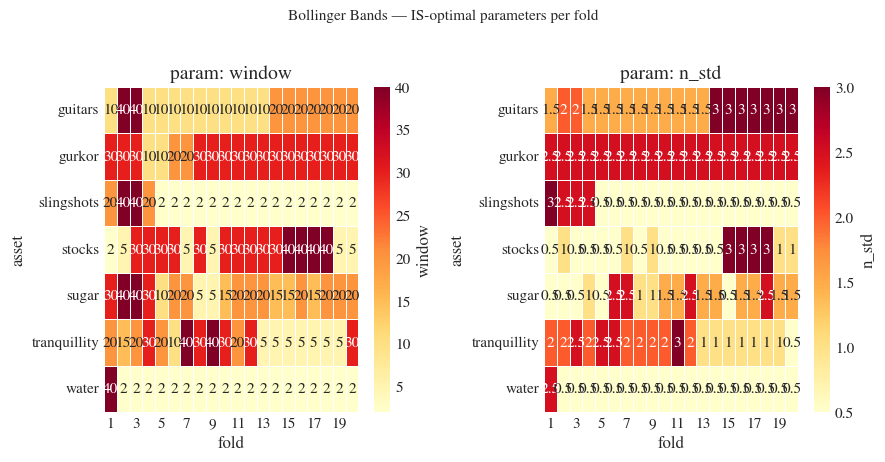


Pairs g/w — fold parameters:


,window,entry_z,exit_z
fold,,,
1,5,1.00,0.5
2,10,2.00,0.5
3,10,2.00,0.5
4,10,2.00,0.5
5,10,2.00,0.5
6,10,2.00,0.5
7,10,2.00,0.5
8,2,0.25,0.5
9,2,0.25,0.5


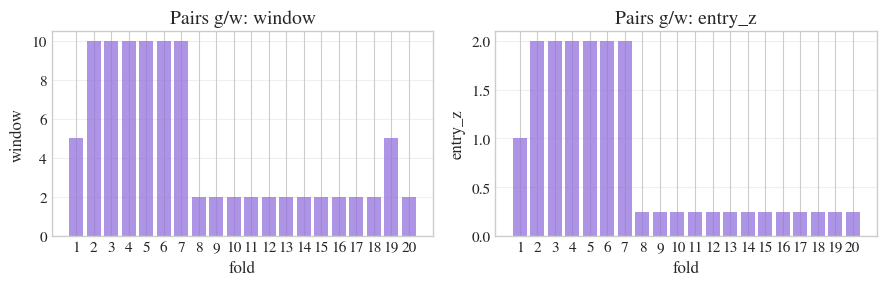


Pairs gu/sl — fold parameters:


,window,entry_z,exit_z
fold,,,
1,30,0.25,0.5
2,30,0.25,0.5
3,5,0.25,0.5
4,5,0.25,0.5
5,5,0.25,0.5
6,5,0.25,0.5
7,5,0.25,0.5
8,5,0.25,0.5
9,5,0.25,0.5


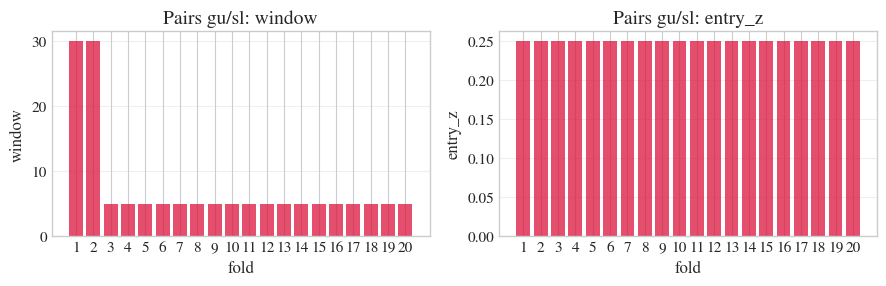

In [16]:
def plot_param_stability(fold_df, params, strategy_name, figsize=None):
    """
    One heatmap per parameter: rows = assets (or single row for portfolio-level),
    columns = folds. Color encodes the chosen parameter value.
    """
    has_asset = "asset" in fold_df.columns
    n_params  = len(params)
    figsize   = figsize or (4.5 * n_params, 4.5 if has_asset else 2.0)
    fig, axes = plt.subplots(1, n_params, figsize=figsize)
    if n_params == 1:
        axes = [axes]

    for ax, param in zip(axes, params):
        if has_asset:
            pivot = fold_df.pivot(index="asset", columns="fold", values=param)
        else:
            pivot = fold_df[["fold", param]].set_index("fold")[[param]].T
            pivot.index = [strategy_name]

        is_int = pd.api.types.is_integer_dtype(fold_df[param])
        fmt    = ".0f" if is_int else ".2g"

        vmin = fold_df[param].min()
        vmax = fold_df[param].max()

        sns.heatmap(
            pivot, annot=True, fmt=fmt, cmap="YlOrRd",
            vmin=vmin, vmax=vmax, linewidths=0.5, ax=ax,
            cbar_kws={"label": param},
        )
        ax.set_title(f"param: {param}")
        ax.set_xlabel("fold")
        ax.set_ylabel("asset" if has_asset else "")
        ax.tick_params(axis="x", labelrotation=0)

    fig.suptitle(f"{strategy_name} — IS-optimal parameters per fold", fontsize=11, y=1.02)
    plt.tight_layout()
    return fig


# MA crossover
fig = plot_param_stability(fold_ma, ["fast", "slow"], "MA crossover")
plt.savefig(output / "param_stability_ma.png", bbox_inches="tight")
plt.show()

# RSI
fig = plot_param_stability(fold_rsi, ["window", "oversold", "overbought"], "RSI")
plt.savefig(output / "param_stability_rsi.png", bbox_inches="tight")
plt.show()

# Bollinger Bands
fig = plot_param_stability(fold_bb, ["window", "n_std"], "Bollinger Bands")
plt.savefig(output / "param_stability_bb.png", bbox_inches="tight")
plt.show()

# Pairs: portfolio-level — just a table with a bar chart overlay
for name, df in [("Pairs g/w", fold_gw), ("Pairs gu/sl", fold_gusl)]:
    print(f"\n{name} — fold parameters:")
    display(df.set_index("fold"))
    fig, axes = plt.subplots(1, 2, figsize=(9, 3))
    for ax, param in zip(axes, ["window", "entry_z"]):
        ax.bar(df["fold"], df[param], color="mediumpurple" if name == "Pairs g/w" else "crimson", alpha=0.75)
        ax.set_title(f"{name}: {param}")
        ax.set_xlabel("fold"); ax.set_ylabel(param)
        ax.set_xticks(df["fold"])
        ax.grid(True, alpha=0.3, axis="y")
    plt.tight_layout()
    fname = "param_stability_gw.png" if name == "Pairs g/w" else "param_stability_gusl.png"
    plt.savefig(output / fname, bbox_inches="tight")
    plt.show()

### 8.2 Bootstrap Sharpe Significance

#### Why bootstrap instead of a t-test?

The most natural question about a strategy is: *could the observed positive Sharpe ratio have arisen purely by chance?*

A classical t-test answers this by assuming daily returns are i.i.d. normal — an assumption financial returns routinely violate (heavy tails, skewness, volatility clustering). The **bootstrap** is distribution-free: it estimates the sampling distribution of the Sharpe ratio directly from the observed returns, with no parametric assumptions imposed.

#### The procedure

For each active (asset, strategy) pair with walk-forward stitched returns $r_1, \ldots, r_T$:

1. **Resample:** draw $T$ observations **with replacement** from $\{r_1, \ldots, r_T\}$ to form a bootstrap sample $r^*_1, \ldots, r^*_T$.
2. **Compute** the annualised Sharpe of the bootstrap sample: $\widehat{SR}^* = \sqrt{365}\; \bar{r}^* / s^*$.
3. **Repeat** steps 1–2 $B = 2000$ times, producing a bootstrap distribution $\{\widehat{SR}^*_b\}_{b=1}^{B}$.
4. **p-value:** $\displaystyle p = \frac{1}{B}\sum_{b=1}^{B}\mathbf{1}[\widehat{SR}^*_b \leq 0]$ — the fraction of bootstrap worlds in which the Sharpe is non-positive.

A small $p$ means the observed positive Sharpe is hard to attribute to sampling noise. We also read off the 5th–95th percentile interval as a 90 % confidence band.

#### Important limitation: iid assumption

Resampling with replacement **destroys temporal order**, which breaks any serial dependence in returns. A trend-following strategy that holds a position for weeks produces runs of correlated positive or negative returns; the bootstrap treats each day as an independent draw, so it underestimates the true variance of the Sharpe estimator. In practice this makes the reported p-value **optimistically small** — the true uncertainty is higher.

Using walk-forward stitched returns (rather than IS bootstrap) partially mitigates this: the strategy was re-tuned across multiple non-overlapping sub-folds, so there is less look-ahead contamination than a single IS evaluation would have. But the iid limitation remains and results should be interpreted with that caveat in mind.

#### The multiple testing problem

We run one hypothesis test per active (asset, strategy) pair. With 7 assets and 6 strategies, there are up to **42 simultaneous tests**. Even if no strategy has any real edge, we expect

$$42 \times 0.05 = 2.1 \text{ false discoveries at } \alpha = 0.05$$

purely by chance. The more tests run without correction, the more likely at least one appears spuriously "significant". This is the **multiple comparisons problem**, and ignoring it is one of the most common sources of false positives in quantitative research.

#### Why Benjamini-Hochberg rather than Bonferroni

| Correction | Controls | Adjusted threshold |
|------------|---------|-------------------|
| None | Nothing | $\alpha = 0.05$ per test |
| Bonferroni | Family-wise error rate (FWER) | $\alpha / m \approx 0.05 / 42 \approx 0.0012$ |
| **BH (used here)** | **False discovery rate (FDR)** | **Adaptive — see below** |

**Bonferroni** controls the probability that *any* null is falsely rejected across the entire family of tests. Because our 42 tests all share the same underlying price data, they are strongly correlated — Bonferroni overcorrects and is far too conservative, discarding real signals alongside noise.

**Benjamini-Hochberg (BH)** controls the **false discovery rate**: the *expected proportion* of rejected nulls that are false positives. At FDR $= 10\%$, of all (asset, strategy) pairs we flag as significant, at most $10\%$ are expected to be spurious. The BH procedure:

1. Sort the $m$ raw p-values: $p_{(1)} \leq p_{(2)} \leq \cdots \leq p_{(m)}$.
2. Find the largest $k$ such that $\displaystyle p_{(k)} \leq \frac{k}{m}\,\alpha_{\text{FDR}}$.
3. Reject hypotheses $1, \ldots, k$.

BH is proven valid under **any positive dependence structure** — a weaker and more realistic assumption for financial data where assets share common market factors. The adjusted p-value for hypothesis $i$ is $\min\bigl(p_{(i)} \cdot m / i,\; 1\bigr)$, taken as a running minimum from right to left to enforce monotonicity.

#### Reading the three heatmaps

| Heatmap | What it shows | How to read it |
|---------|--------------|---------------|
| **Sharpe** | Point estimate of annualised Sharpe | Positive = earns a risk premium on average |
| **Raw p-value** | $P(SR \leq 0)$ before correction | Directional evidence; $< 0.05$ is nominally significant |
| **BH-adjusted p-value** | After correcting for ~42 simultaneous tests | The honest bar — $< 0.10$ survives multiple testing at FDR 10 % |

The strongest evidence the notebook can offer is a cell that is (i) positive in the Sharpe heatmap, (ii) green in the BH-adjusted heatmap, and (iii) consistent across most folds in the dot plot (§8.1). A strategy that clears only the raw threshold but not the BH threshold should be treated with scepticism — it may simply be one of the lucky false discoveries expected from running 42 tests.

Raw bootstrap p-values P(SR ≤ 0):


,MA crossover,RSI,Bollinger,Pairs g/w,Pairs gu/sl,Pairs g/w LS,Pairs gu/sl LS,Buy & Hold
gurkor,0.034,0.207,0.021,0.013,NaN,0.004,NaN,0.009
guitars,0.062,0.755,0.704,NaN,0.000,NaN,0.0,0.707
slingshots,0.258,0.345,0.085,NaN,0.002,NaN,0.0,0.560
stocks,0.526,0.248,0.527,NaN,NaN,NaN,NaN,0.506
sugar,0.433,0.667,0.787,NaN,NaN,NaN,NaN,0.778
water,0.227,0.128,0.075,0.000,NaN,0.000,NaN,0.073
tranquillity,0.466,0.829,0.725,NaN,NaN,NaN,NaN,0.446



BH-adjusted p-values (FDR control):


,MA crossover,RSI,Bollinger,Pairs g/w,Pairs gu/sl,Pairs g/w LS,Pairs gu/sl LS,Buy & Hold
gurkor,0.111,0.438,0.076,0.052,NaN,0.021,NaN,0.040
guitars,0.186,0.809,0.809,NaN,0.000,NaN,0.0,0.809
slingshots,0.464,0.591,0.204,NaN,0.012,NaN,0.0,0.720
stocks,0.703,0.464,0.703,NaN,NaN,NaN,NaN,0.703
sugar,0.698,0.809,0.809,NaN,NaN,NaN,NaN,0.809
water,0.454,0.288,0.193,0.000,NaN,0.000,NaN,0.193
tranquillity,0.699,0.829,0.809,NaN,NaN,NaN,NaN,0.698


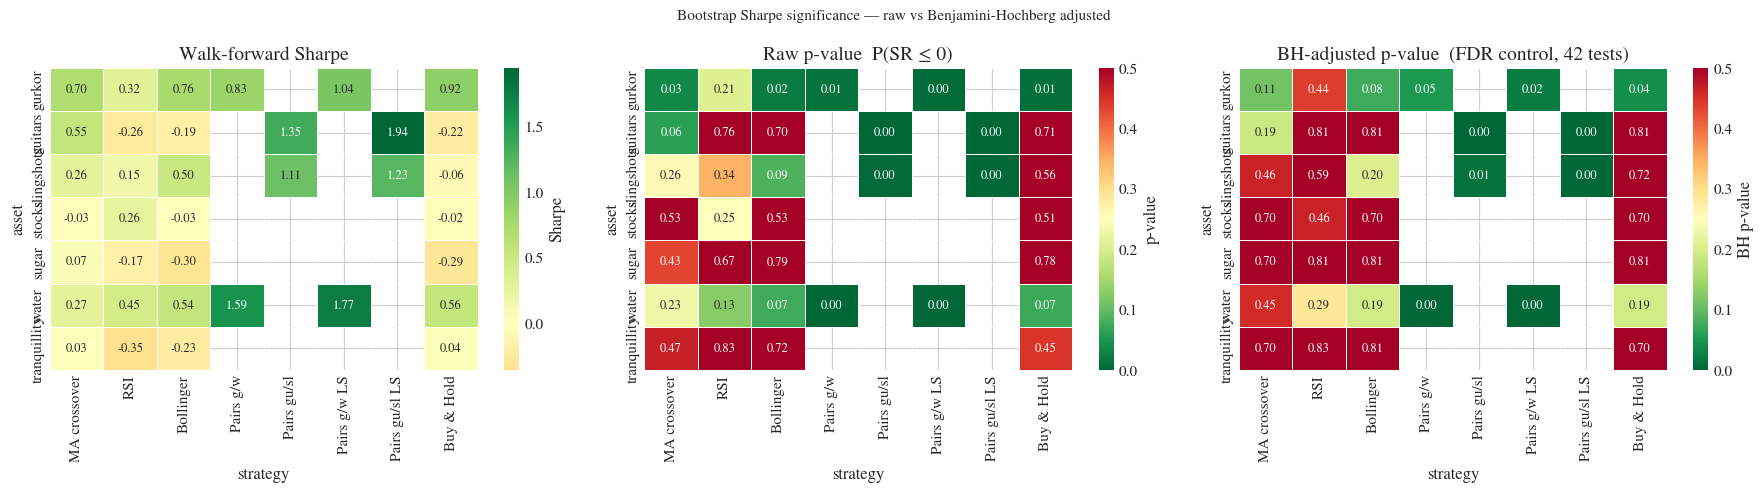

In [17]:
N_BOOT = 2000

def bootstrap_sr_pvalue(ret_series, n_boot=N_BOOT, ann=365, random_state=42):
    """Bootstrap p-value: fraction of resampled Sharpes <= 0."""
    rng  = np.random.default_rng(random_state)
    vals = ret_series.dropna().values
    if len(vals) < 10 or (vals == 0).all():
        return np.nan, np.nan, np.nan
    n    = len(vals)
    boot_srs = []
    for _ in range(n_boot):
        s   = rng.choice(vals, size=n, replace=True)
        vol = s.std() * np.sqrt(ann)
        boot_srs.append(s.mean() * ann / vol if vol > 0 else np.nan)
    boot_srs = np.array(boot_srs)
    actual_sr = vals.mean() * ann / (vals.std() * np.sqrt(ann))
    lo, hi    = np.nanpercentile(boot_srs, [5, 95])
    p_val     = float(np.nanmean(boot_srs <= 0))
    return round(actual_sr, 3), round(p_val, 3), (round(lo, 3), round(hi, 3))

# compute per (asset, strategy)
sr_mat = pd.DataFrame(index=prices_is.columns, columns=[l for l,_,_ in wf_specs])
pv_mat = pd.DataFrame(index=prices_is.columns, columns=[l for l,_,_ in wf_specs])

for label, wf_ret, _ in wf_specs:
    for col in prices_is.columns:
        sr, pv, _ = bootstrap_sr_pvalue(wf_ret[col])
        sr_mat.loc[col, label] = sr
        pv_mat.loc[col, label] = pv

sr_mat = sr_mat.astype(float)
pv_mat = pv_mat.astype(float)

# ── Benjamini-Hochberg FDR correction ────────────────────────────────────────
# Only adjust active (asset, strategy) pairs — flat pairs are excluded.
ever_active = pd.DataFrame({
    label: {col: (wf_ret[col] != 0).any() for col in prices_is.columns}
    for label, wf_ret, _ in wf_specs
})

def bh_adjust(pv_matrix, active_mask):
    """
    Benjamini-Hochberg adjustment across all active tests.
    Returns a DataFrame of BH-adjusted p-values (NaN where inactive).
    """
    flat_idx  = [(r, c) for r in pv_matrix.index for c in pv_matrix.columns
                 if active_mask.loc[r, c] and not pd.isna(pv_matrix.loc[r, c])]
    if not flat_idx:
        return pv_matrix.copy()
    raw = np.array([pv_matrix.loc[r, c] for r, c in flat_idx])
    m   = len(raw)
    order = np.argsort(raw)
    rank  = np.empty(m, dtype=int)
    rank[order] = np.arange(1, m + 1)
    # BH adjusted: p_adj_i = p_i * m / rank_i, then take running min from right
    adj = raw * m / rank
    # enforce monotonicity (take cumulative min from the largest rank downward)
    for i in order[::-1]:
        right_neighbors = [adj[j] for j in range(m) if rank[j] > rank[i]]
        if right_neighbors:
            adj[i] = min(adj[i], min(right_neighbors))
    adj = np.minimum(adj, 1.0)
    pv_bh = pv_matrix.copy().astype(float) * np.nan
    for (r, c), v in zip(flat_idx, adj):
        pv_bh.loc[r, c] = round(float(v), 3)
    return pv_bh

pv_bh = bh_adjust(pv_mat, ever_active)

print("Raw bootstrap p-values P(SR ≤ 0):")
display(pv_mat.round(5))
print("\nBH-adjusted p-values (FDR control):")
display(pv_bh.round(5))

# ── Annotation helper ─────────────────────────────────────────────────────────
def make_annot(df, exp_flag):
    annot = df.copy().astype(object)
    for col in df.columns:
        for idx in df.index:
            v = df.loc[idx, col]
            annot.loc[idx, col] = "flat" if exp_flag.loc[idx, col] else (f"{v:.2f}" if not pd.isna(v) else "n/a")
    return annot

# ── Three heatmaps: Sharpe | raw p | BH-adjusted p ───────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

annot_sr = make_annot(sr_mat, ~ever_active)
sns.heatmap(sr_mat, annot=annot_sr, fmt="", cmap="RdYlGn", center=0,
            linewidths=0.5, ax=axes[0], cbar_kws={"label": "Sharpe"}, annot_kws={"size": 9})
axes[0].set_title("Walk-forward Sharpe")
axes[0].set_ylabel("asset"); axes[0].set_xlabel("strategy")

pv_plot = pv_mat.where(ever_active)
annot_pv = make_annot(pv_mat, ~ever_active)
sns.heatmap(pv_plot, annot=annot_pv, fmt="", cmap="RdYlGn_r", vmin=0, vmax=0.5,
            linewidths=0.5, ax=axes[1], cbar_kws={"label": "p-value"}, annot_kws={"size": 9})
axes[1].set_title("Raw p-value  P(SR ≤ 0)")
axes[1].set_ylabel("asset"); axes[1].set_xlabel("strategy")

bh_plot = pv_bh.where(ever_active)
annot_bh = make_annot(pv_bh, ~ever_active)
sns.heatmap(bh_plot, annot=annot_bh, fmt="", cmap="RdYlGn_r", vmin=0, vmax=0.5,
            linewidths=0.5, ax=axes[2], cbar_kws={"label": "BH p-value"}, annot_kws={"size": 9})
axes[2].set_title("BH-adjusted p-value  (FDR control, 42 tests)")
axes[2].set_ylabel("asset"); axes[2].set_xlabel("strategy")

plt.suptitle("Bootstrap Sharpe significance — raw vs Benjamini-Hochberg adjusted", fontsize=11)
plt.tight_layout()
plt.savefig(output / "bootstrap_sharpe.png", bbox_inches="tight")
plt.show()


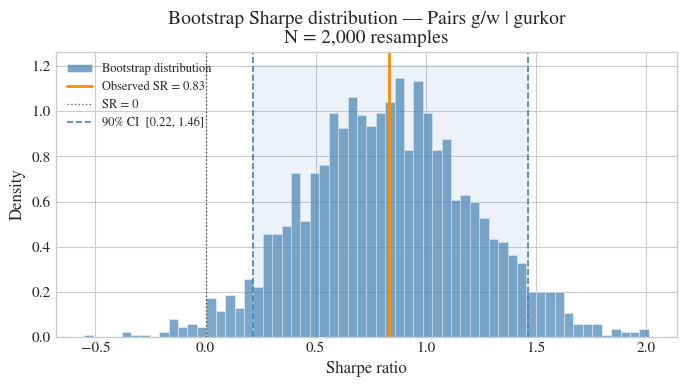

In [25]:
# ── Bootstrap Sharpe distribution: Pairs g/w | gurkor ────────────────────────
_STRATEGY = "Pairs g/w"
_ASSET    = "gurkor"

_wf_ret = next(wf_ret for label, wf_ret, _ in wf_specs if label == _STRATEGY)
_vals   = _wf_ret[_ASSET].dropna().values

# Re-run bootstrap keeping the full distribution
_rng      = np.random.default_rng(42)
_n        = len(_vals)
_boot_srs = []
for _ in range(N_BOOT):
    _s   = _rng.choice(_vals, size=_n, replace=True)
    _vol = _s.std() * np.sqrt(365)
    _boot_srs.append(_s.mean() * 365 / _vol if _vol > 0 else np.nan)
_boot_srs  = np.array(_boot_srs)
_actual_sr = _vals.mean() * 365 / (_vals.std() * np.sqrt(365))
_lo, _hi   = np.nanpercentile(_boot_srs, [5, 95])
_p_val     = float(np.nanmean(_boot_srs <= 0))

fig, ax = plt.subplots(figsize=(7, 4))

ax.hist(_boot_srs[~np.isnan(_boot_srs)], bins=60, color="steelblue",
        alpha=0.7, edgecolor="white", linewidth=0.4, density=True,
        label="Bootstrap distribution")

ax.axvline(_actual_sr, color="darkorange", linewidth=2.0, linestyle="-",
           label=f"Observed SR = {_actual_sr:.2f}")
ax.axvline(0, color="black", linewidth=1.0, linestyle=":", alpha=0.6,
           label="SR = 0")
ax.axvline(_lo, color="steelblue", linewidth=1.2, linestyle="--",
           label=f"90% CI  [{_lo:.2f}, {_hi:.2f}]")
ax.axvline(_hi, color="steelblue", linewidth=1.2, linestyle="--")

ax.fill_betweenx([0, ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else 1],
                 _lo, _hi, alpha=0.10, color="steelblue")

ax.set_xlabel("Sharpe ratio")
ax.set_ylabel("Density")
ax.set_title(f"Bootstrap Sharpe distribution — {_STRATEGY} | {_ASSET}\n"
              f"N = {N_BOOT:,} resamples")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(output / "bootstrap_sr_pairs_gw_gurkor.png", bbox_inches="tight")
plt.show()


### 8.3 Per-Asset Breakdown

Each **(asset, strategy)** pair is evaluated independently. The heatmap shows the walk-forward pseudo-OoS Sharpe for every pair — pairs strategies show "flat" for the 5 assets they never trade. This is the primary performance summary: consistent positive Sharpe across most assets indicates a genuine signal; isolated bright cells suggest the strategy works by luck on one asset.

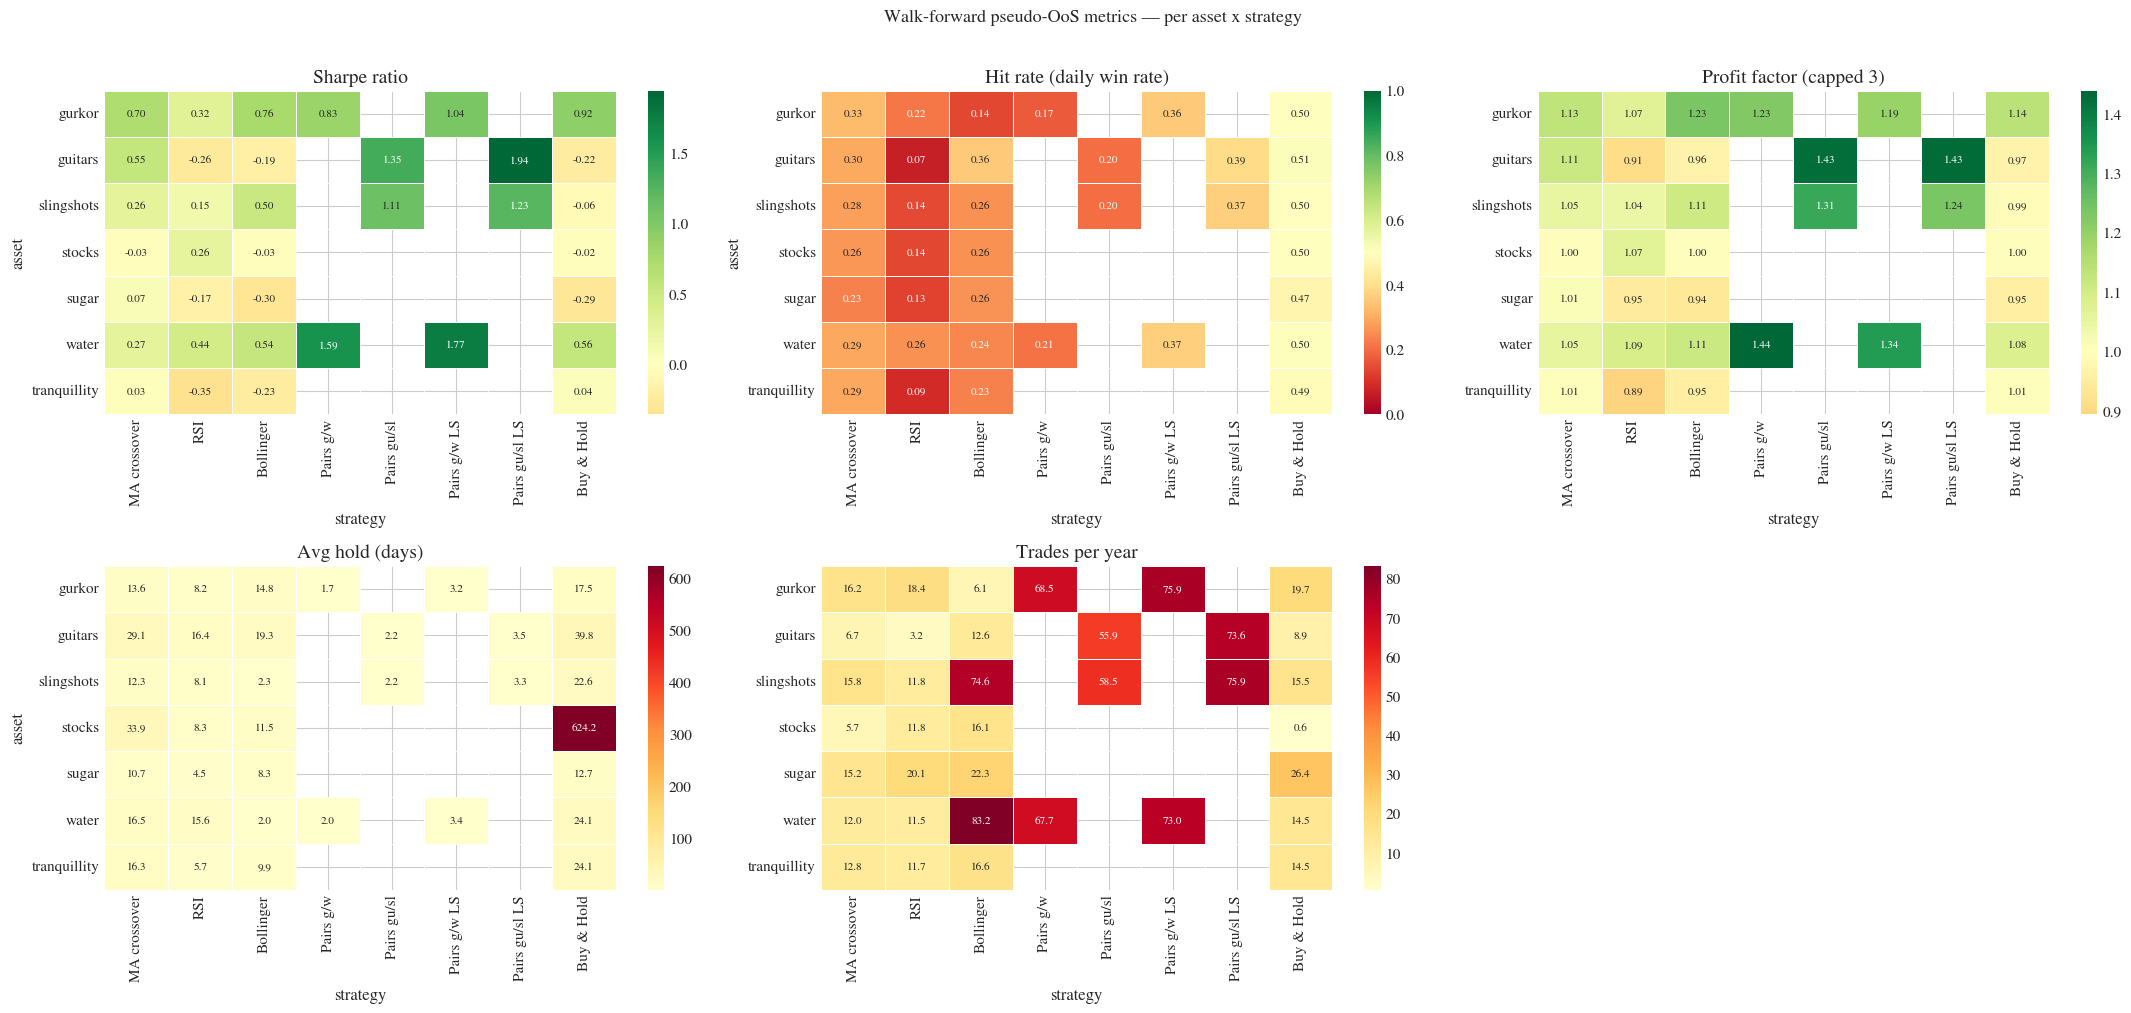

Walk-forward Sharpe:
              MA crossover    RSI  Bollinger  Pairs g/w  Pairs gu/sl  \
gurkor               0.697  0.316      0.755      0.832          NaN   
guitars              0.547 -0.260     -0.189        NaN        1.348   
slingshots           0.261  0.152      0.504        NaN        1.114   
stocks              -0.027  0.257     -0.025        NaN          NaN   
sugar                0.066 -0.172     -0.301        NaN          NaN   
water                0.271  0.445      0.535      1.587          NaN   
tranquillity         0.027 -0.352     -0.226        NaN          NaN   

              Pairs g/w LS  Pairs gu/sl LS  Buy & Hold  
gurkor               1.043             NaN       0.918  
guitars                NaN           1.943      -0.219  
slingshots             NaN           1.227      -0.064  
stocks                 NaN             NaN      -0.017  
sugar                  NaN             NaN      -0.294  
water                1.770             NaN       0.559  
tra

In [19]:
def _wf_asset_sharpe(ret_series, ann=365):
    sr = ret_series.dropna()
    if sr.empty or (sr == 0).all():
        return np.nan
    v = sr.std() * np.sqrt(ann)
    return sr.mean() * ann / v if v > 0 else np.nan

def _wf_asset_hit_rate(ret_series):
    sr = ret_series.dropna()
    if sr.empty or (sr == 0).all():
        return np.nan
    return float((sr > 0).mean())

def _wf_asset_profit_factor(ret_series):
    sr = ret_series.dropna()
    if sr.empty or (sr == 0).all():
        return np.nan
    wins   = sr[sr > 0].sum()
    losses = sr[sr < 0].sum()
    return float(wins / abs(losses)) if losses != 0 else np.nan

def _wf_asset_avg_hold(ret_series):
    sr = ret_series.dropna()
    if sr.empty or (sr == 0).all():
        return np.nan
    active   = (sr != 0).astype(int)
    n_trades = int(((active == 1) & (active.shift(1, fill_value=0) == 0)).sum())
    return float(active.sum() / n_trades) if n_trades > 0 else np.nan

def _wf_asset_trades_per_year(ret_series, ann=365):
    sr = ret_series.dropna()
    if sr.empty or (sr == 0).all():
        return np.nan
    active   = (sr != 0).astype(int)
    n_trades = int(((active == 1) & (active.shift(1, fill_value=0) == 0)).sum())
    return float(n_trades / (len(sr) / ann)) if len(sr) > 0 else np.nan

sharpe_wf  = {}
hitrate_wf = {}
pf_wf      = {}
hold_wf    = {}
tpy_wf     = {}
exposure_wf = {}
for label, wf_ret, _ in wf_specs:
    sharpe_wf[label]   = {col: _wf_asset_sharpe(wf_ret[col])         for col in prices_is.columns}
    hitrate_wf[label]  = {col: _wf_asset_hit_rate(wf_ret[col])       for col in prices_is.columns}
    pf_wf[label]       = {col: _wf_asset_profit_factor(wf_ret[col])  for col in prices_is.columns}
    hold_wf[label]     = {col: _wf_asset_avg_hold(wf_ret[col])       for col in prices_is.columns}
    tpy_wf[label]      = {col: _wf_asset_trades_per_year(wf_ret[col]) for col in prices_is.columns}
    exposure_wf[label] = {col: float((wf_ret[col] != 0).mean())       for col in prices_is.columns}

per_asset_wf    = pd.DataFrame(sharpe_wf)
per_hitrate_wf  = pd.DataFrame(hitrate_wf)
per_pf_wf       = pd.DataFrame(pf_wf)
per_hold_wf     = pd.DataFrame(hold_wf)
per_tpy_wf      = pd.DataFrame(tpy_wf)
per_exposure_wf = pd.DataFrame(exposure_wf)

def _annot_wf(value_df, exp_df, fmt="{:.2f}"):
    annot = value_df.copy().astype(object)
    for col in annot.columns:
        for idx in annot.index:
            exp = exp_df.loc[idx, col]
            v   = value_df.loc[idx, col]
            annot.loc[idx, col] = "flat" if exp == 0 else ("n/a" if pd.isna(v) else fmt.format(v))
    return annot

fig, axes = plt.subplots(2, 3, figsize=(22, 10))

panels = [
    (axes[0, 0], per_asset_wf,   "Sharpe ratio",                      "RdYlGn", 0,   None, None, "{:.2f}"),
    (axes[0, 1], per_hitrate_wf, "Hit rate (daily win rate)",          "RdYlGn", 0.5, 0,   1,    "{:.2f}"),
    (axes[0, 2], per_pf_wf.clip(upper=3),
                 per_pf_wf,      "Profit factor (capped 3)",           "RdYlGn", 1,   0,   None, "{:.2f}"),
    (axes[1, 0], per_hold_wf,    "Avg hold (days)",                    "YlOrRd", None,None, None, "{:.1f}"),
    (axes[1, 1], per_tpy_wf,     "Trades per year",                    "YlOrRd", None,None, None, "{:.1f}"),
]

# unpack profit factor separately (uses raw df for annotations but clipped for colour)
for entry in panels[:2]:
    ax, df, title, cmap, center, vmin, vmax, fmt = entry
    annot = _annot_wf(df, per_exposure_wf, fmt)
    kw = dict(annot=annot, fmt="", cmap=cmap, center=center, linewidths=0.5,
              ax=ax, annot_kws={"size": 8})
    if vmin is not None: kw["vmin"] = vmin
    if vmax is not None: kw["vmax"] = vmax
    sns.heatmap(df, **kw)
    ax.set_title(title); ax.set_ylabel("asset"); ax.set_xlabel("strategy")

# profit factor: colour on clipped df, annotations from raw
ax, df_clipped, df_raw, title, cmap, center, vmin, vmax, fmt = (*panels[2][:2], per_pf_wf, *panels[2][3:])
annot = _annot_wf(df_raw, per_exposure_wf, fmt)
sns.heatmap(df_clipped, annot=annot, fmt="", cmap=cmap, center=center,
            linewidths=0.5, ax=ax, annot_kws={"size": 8})
ax.set_title(title); ax.set_ylabel(""); ax.set_xlabel("strategy")

for entry in panels[3:]:
    ax, df, title, cmap, center, vmin, vmax, fmt = entry
    annot = _annot_wf(df, per_exposure_wf, fmt)
    kw = dict(annot=annot, fmt="", cmap=cmap, linewidths=0.5,
              ax=ax, annot_kws={"size": 8})
    if center is not None: kw["center"] = center
    sns.heatmap(df, **kw)
    ax.set_title(title); ax.set_ylabel("asset" if ax in axes[:, 0] else ""); ax.set_xlabel("strategy")

axes[1, 2].set_visible(False)

plt.suptitle("Walk-forward pseudo-OoS metrics — per asset x strategy", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(output / "per_asset_metrics.png", bbox_inches="tight")
plt.show()

print("Walk-forward Sharpe:");       print(per_asset_wf.round(3))
print("\nWalk-forward Hit rate:");   print(per_hitrate_wf.round(3))
print("\nWalk-forward Profit factor:"); print(per_pf_wf.round(3))
print("\nWalk-forward Avg hold (days):"); print(per_hold_wf.round(1))
print("\nWalk-forward Trades/year:"); print(per_tpy_wf.round(1))


## 9. Summary

| Validation method | Question answered |
|-------------------|------------------|
| **Walk-forward** | Does IS parameter selection work consistently across multiple sub-windows? |
| **Parameter stability** | Are optimal parameters stable or noise-driven? |
| **Bootstrap CI** | Is the walk-forward Sharpe statistically distinguishable from zero? |
| **Per-asset breakdown** | Does performance hold across all assets or just a lucky few? |
| **Walk-forward MVP** | Does minimum-variance allocation hold up across IS sub-folds? |

**Bottom-line:** all evidence is based on walk-forward pseudo-OoS within the IS window. A strategy that genuinely clears the bar would need:
- Positive walk-forward Sharpe with 90% CI entirely above zero
- Consistent positive Sharpe across most folds and most assets
- Stable parameters fold-to-fold
- Walk-forward MVP Sharpe competitive with naive equal-weight

## 10. Portfolio Allocation — Efficient Frontier (Buy-and-Hold)

So far every strategy has treated all 7 assets with equal weight. A natural question is: **what passive weight vector over the assets is actually efficient?** Using IS log-returns we estimate each asset's expected return and covariance, then map the full risk-return opportunity set.

### Mean-Variance framework

For a long-only portfolio $\mathbf{w} \geq 0$, $\mathbf{1}^\top \mathbf{w} = 1$ over the $n$ assets:

$$\mu_p = \mathbf{w}^\top \boldsymbol{\mu}, \qquad \sigma_p = \sqrt{\mathbf{w}^\top \boldsymbol{\Sigma}\, \mathbf{w}}$$

The **efficient frontier** traces the minimum-variance portfolio at every achievable return level. Two special points:

| Portfolio | Definition |
|-----------|-----------|
| **MVP** | Minimum variance — no return constraint, leftmost frontier point |
| **Max-Sharpe** | Highest $\mu_p / \sigma_p$ — tangency point at $r_f = 0$ |
| **Equal-weight** | $w_i = 1/7$ — the implicit allocation used throughout the notebook |

**Estimation discipline:** $\boldsymbol{\mu}$ and $\boldsymbol{\Sigma}$ estimated on IS data only.

IS annualised return per asset:
gurkor          0.0590
guitars        -0.0615
slingshots     -0.0123
stocks          0.0013
sugar          -0.0720
water           0.0318
tranquillity    0.0025
dtype: float64

IS annualised volatility per asset:
[0.078  0.3101 0.3107 0.2841 0.3129 0.062  0.2406]

IS correlation matrix:


,gurkor,guitars,slingshots,stocks,sugar,water,tranquillity
gurkor,1.000,-0.290,-0.255,-0.070,-0.078,0.627,-0.087
guitars,-0.290,1.000,0.493,0.047,0.217,-0.284,0.186
slingshots,-0.255,0.493,1.000,0.041,0.112,-0.175,0.119
stocks,-0.070,0.047,0.041,1.000,-0.018,-0.056,0.011
sugar,-0.078,0.217,0.112,-0.018,1.000,-0.079,0.154
water,0.627,-0.284,-0.175,-0.056,-0.079,1.000,-0.107
tranquillity,-0.087,0.186,0.119,0.011,0.154,-0.107,1.000



MVP weights:
gurkor          0.221
guitars         0.049
slingshots      0.029
stocks          0.038
sugar           0.020
water           0.598
tranquillity    0.045
dtype: float64
  vol=0.0496  ret=0.0273  SR=0.551

Max-Sharpe weights:
gurkor          0.818
guitars         0.000
slingshots      0.042
stocks          0.016
sugar           0.000
water           0.101
tranquillity    0.023
dtype: float64
  vol=0.0654  ret=0.0510  SR=0.779

Equal-weight:
  vol=0.1128  ret=-0.0073  SR=-0.065


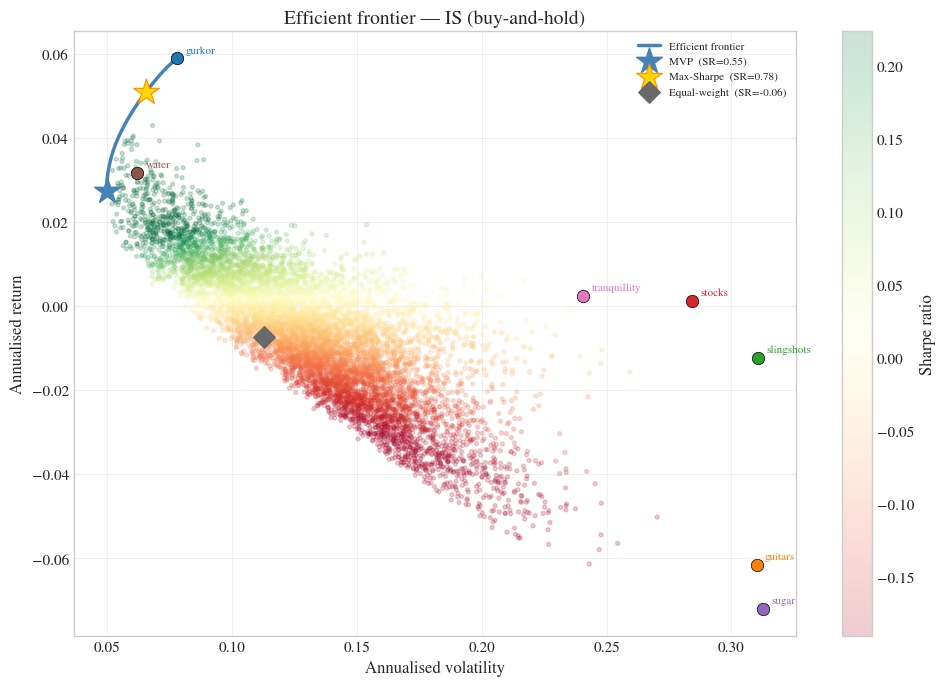

In [20]:
from scipy.optimize import minimize

# ── IS asset log-returns ──────────────────────────────────────────────────────
log_ret_is = np.log(prices_is).diff().dropna()

mu_a    = log_ret_is.mean() * 365
Sigma_a = log_ret_is.cov()  * 365
assets  = list(mu_a.index)
n_a     = len(assets)

print("IS annualised return per asset:")
print(mu_a.round(4))
print("\nIS annualised volatility per asset:")
print(np.sqrt(np.diag(Sigma_a.values)).round(4))
print("\nIS correlation matrix:")
display(log_ret_is.corr().round(3))

# ── optimisation helpers ──────────────────────────────────────────────────────
def port_vol(w): return float(np.sqrt(w @ Sigma_a.values @ w))
def port_ret(w): return float(w @ mu_a.values)
def neg_sharpe(w): v = port_vol(w); return -port_ret(w) / v if v > 1e-10 else 0.0

bounds   = [(0.0, 1.0)] * n_a
sum_to_1 = {"type": "eq", "fun": lambda w: w.sum() - 1}
w0       = np.ones(n_a) / n_a

mvp = minimize(port_vol,   w0, method="SLSQP", bounds=bounds, constraints=[sum_to_1])
msr = minimize(neg_sharpe, w0, method="SLSQP", bounds=bounds, constraints=[sum_to_1])
mvp_w, msr_w = mvp.x, msr.x
ew_w = np.ones(n_a) / n_a

print("\nMVP weights:");    print(pd.Series(mvp_w, index=assets).round(3))
print(f"  vol={port_vol(mvp_w):.4f}  ret={port_ret(mvp_w):.4f}  SR={port_ret(mvp_w)/port_vol(mvp_w):.3f}")
print("\nMax-Sharpe weights:"); print(pd.Series(msr_w, index=assets).round(3))
print(f"  vol={port_vol(msr_w):.4f}  ret={port_ret(msr_w):.4f}  SR={port_ret(msr_w)/port_vol(msr_w):.3f}")
print("\nEqual-weight:")
print(f"  vol={port_vol(ew_w):.4f}  ret={port_ret(ew_w):.4f}  SR={port_ret(ew_w)/port_vol(ew_w):.3f}")

asset_colors = dict(zip(assets, plt.cm.tab10.colors))

# ── frontier helper ───────────────────────────────────────────────────────────
def compute_frontier(mu_vec, Sigma_mat, mvp_ret, n_pts=80):
    def _vol(w): return float(np.sqrt(w @ Sigma_mat @ w))
    _w0 = np.ones(len(mu_vec)) / len(mu_vec)
    _b  = [(0.0, 1.0)] * len(mu_vec)
    _s1 = {"type": "eq", "fun": lambda w: w.sum() - 1}
    vols = []
    for mu_t in np.linspace(mvp_ret, mu_vec.max(), n_pts):
        rc  = {"type": "eq", "fun": lambda w, m=mu_t: w @ mu_vec - m}
        res = minimize(_vol, _w0, method="SLSQP", bounds=_b, constraints=[_s1, rc])
        vols.append(res.fun if res.success else np.nan)
    return np.linspace(mvp_ret, mu_vec.max(), n_pts), np.array(vols)

# ── IS frontier + Monte Carlo ─────────────────────────────────────────────────
is_target_rets, is_frontier_vols = compute_frontier(mu_a.values, Sigma_a.values, port_ret(mvp_w))

rng        = np.random.default_rng(42)
mc_w       = rng.dirichlet(np.ones(n_a), size=8_000)
mc_rets_is = mc_w @ mu_a.values
mc_vols_is = np.sqrt(np.einsum("ij,jk,ik->i", mc_w, Sigma_a.values, mc_w))
mc_sr_is   = mc_rets_is / mc_vols_is

# ── Plot: IS efficient frontier ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))

sc = ax.scatter(mc_vols_is, mc_rets_is, c=mc_sr_is, cmap="RdYlGn", alpha=0.2, s=8,
                vmin=np.percentile(mc_sr_is, 5), vmax=np.percentile(mc_sr_is, 95), zorder=1)
plt.colorbar(sc, ax=ax, label="Sharpe ratio")

ax.plot(is_frontier_vols, is_target_rets, color="steelblue", linewidth=2.5, zorder=2,
        label="Efficient frontier")

mvp_vl, mvp_r = port_vol(mvp_w), port_ret(mvp_w)
ax.scatter(mvp_vl, mvp_r, marker="*", s=380, color="steelblue", zorder=5,
           label=f"MVP  (SR={mvp_r/mvp_vl:.2f})")

msr_vl = float(np.sqrt(msr_w @ Sigma_a.values @ msr_w))
msr_r  = float(msr_w @ mu_a.values)
ax.scatter(msr_vl, msr_r, marker="*", s=380, color="gold",
           edgecolors="darkorange", linewidth=0.8, zorder=5,
           label=f"Max-Sharpe  (SR={msr_r/msr_vl:.2f})")

ew_vl = float(np.sqrt(ew_w @ Sigma_a.values @ ew_w))
ew_r  = float(ew_w @ mu_a.values)
ax.scatter(ew_vl, ew_r, marker="D", s=120, color="dimgray", zorder=5,
           label=f"Equal-weight  (SR={ew_r/ew_vl:.2f})")

for i, asset in enumerate(assets):
    sv = np.sqrt(Sigma_a.values[i, i])
    ar = mu_a.values[i]
    ax.scatter(sv, ar, s=80, color=asset_colors[asset],
               edgecolors="black", linewidth=0.5, zorder=4)
    ax.annotate(asset, (sv, ar), textcoords="offset points",
                xytext=(6, 4), fontsize=8, color=asset_colors[asset])

ax.set_xlabel("Annualised volatility")
ax.set_ylabel("Annualised return")
ax.set_title("Efficient frontier — IS (buy-and-hold)")
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(output / "efficient_frontier.png", bbox_inches="tight")
plt.show()


### 10.1 Walk-Forward MVP Allocation (IS Sub-Folds)

Rather than fixing a single set of MVP weights over all IS data, we re-estimate the weights on each expanding IS sub-fold and apply them to the immediately following sub-fold. This stays entirely within the IS window — the real OoS data is not touched here.

```
IS sub-fold 1 | val 1   →  MVP weights from sub-fold 1 applied to val 1
IS sub-fold 2 | val 2   →  MVP weights from sub-fold 2 applied to val 2
...
```

**What this tests:** whether the minimum-variance weights are stable and useful within the IS period itself, before committing to the single OoS evaluation in Section 14.1. If performance is consistently positive across sub-folds, the covariance structure was stable enough for walk-forward allocation to work.

Fold 1: IS=238 days  OoS=[1740,1977]  MVP SR=1.042  top weight: gurkor=0.52
Fold 2: IS=476 days  OoS=[1978,2215]  MVP SR=0.790  top weight: water=0.48
Fold 3: IS=714 days  OoS=[2216,2453]  MVP SR=-0.230  top weight: water=0.77
Fold 4: IS=952 days  OoS=[2454,2691]  MVP SR=2.386  top weight: water=0.62
Fold 5: IS=1190 days  OoS=[2692,2929]  MVP SR=1.127  top weight: water=0.37
Fold 6: IS=1428 days  OoS=[2930,3167]  MVP SR=2.922  top weight: water=0.79
Fold 7: IS=1666 days  OoS=[3168,3405]  MVP SR=1.713  top weight: water=0.59
Fold 8: IS=1904 days  OoS=[3406,3643]  MVP SR=0.349  top weight: water=0.55
Fold 9: IS=2142 days  OoS=[3644,3881]  MVP SR=0.530  top weight: water=0.65
Fold 10: IS=2380 days  OoS=[3882,4119]  MVP SR=-0.200  top weight: water=0.62

MVP weights per fold:


,gurkor,guitars,slingshots,stocks,sugar,water,tranquillity
Fold 1,0.519,0.000,0.028,0.045,0.031,0.267,0.111
Fold 2,0.341,0.000,0.020,0.040,0.040,0.478,0.081
Fold 3,0.092,0.057,0.015,0.018,0.007,0.768,0.043
Fold 4,0.180,0.044,0.024,0.027,0.049,0.619,0.057
Fold 5,0.369,0.042,0.071,0.020,0.024,0.372,0.103
Fold 6,0.032,0.079,0.028,0.026,0.008,0.790,0.037
Fold 7,0.203,0.099,0.005,0.022,0.052,0.595,0.023
Fold 8,0.272,0.064,0.035,0.015,0.045,0.552,0.017
Fold 9,0.235,0.064,0.003,0.023,0.021,0.654,0.000
Fold 10,0.174,0.106,0.035,0.033,0.019,0.618,0.015



Walk-forward stitched OoS metrics:
  WF-MVP           SR=0.916  vol=0.050  maxDD=-0.076  calmar=0.603
  Equal-weight     SR=-0.041  vol=0.114  maxDD=-0.320  calmar=-0.015
  Water only       SR=0.747  vol=0.061  maxDD=-0.102  calmar=0.445


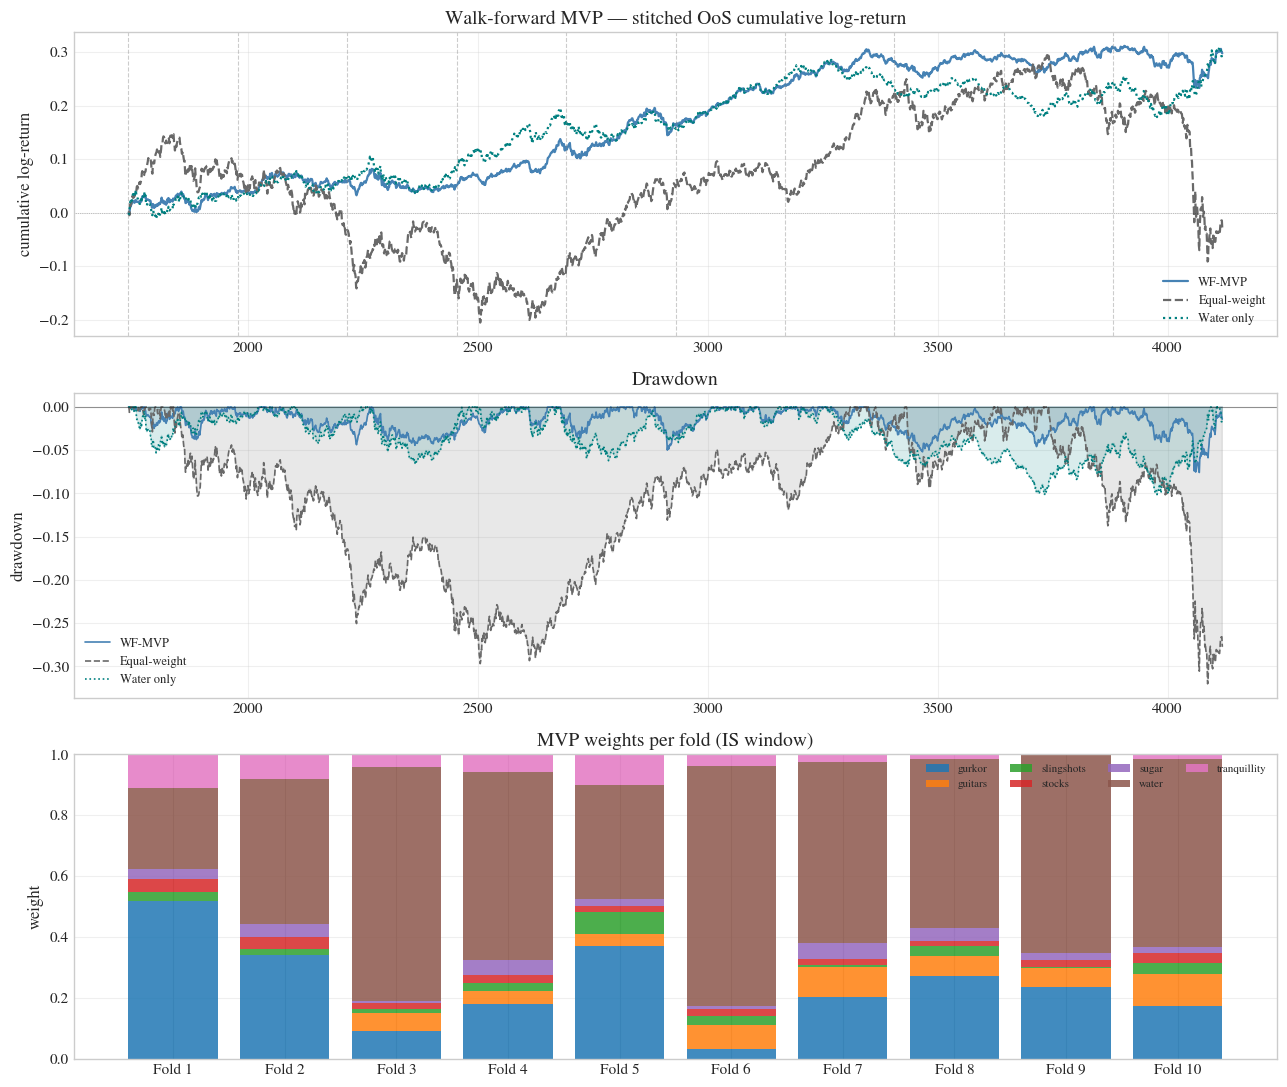

In [21]:
WF_FOLDS_MV = 10
CAL_WINDOW  = 200  # days used to estimate covariance matrix

log_ret_wf = np.log(prices_is).diff().dropna()
n_wf       = len(log_ret_wf)
fold_size  = n_wf // (WF_FOLDS_MV + 1)

def compute_mvp_weights(log_ret_window):
    mu_w  = log_ret_window.mean() * 365
    Sig_w = log_ret_window.cov()  * 365
    n     = len(mu_w)
    def _vol(w): return float(np.sqrt(w @ Sig_w.values @ w))
    res = minimize(_vol, np.ones(n) / n, method="SLSQP",
                   bounds=[(0, 1)] * n,
                   constraints={"type": "eq", "fun": lambda w: w.sum() - 1})
    return res.x if res.success else np.ones(n) / n

# ── walk-forward loop ─────────────────────────────────────────────────────────
wf_chunks   = []   # MVP walk-forward OoS returns
ew_chunks   = []   # equal-weight OoS returns  (for comparison)
h2o_chunks  = []   # water-only OoS returns    (for comparison)
fold_info   = []

water_idx = assets.index("water")
water_w_vec = np.array([1.0 if a == "water" else 0.0 for a in assets])

for fold in range(1, WF_FOLDS_MV + 1):
    is_end  = fold * fold_size
    oos_end = min((fold + 1) * fold_size, n_wf)
    if oos_end <= is_end:
        continue

    lr_is  = log_ret_wf.iloc[:is_end]
    lr_oos = log_ret_wf.iloc[is_end:oos_end]

    w_mvp  = compute_mvp_weights(lr_is.iloc[-CAL_WINDOW:])

    mvp_ret = lr_oos @ w_mvp
    ew_ret  = lr_oos @ (np.ones(n_a) / n_a)
    h2o_ret = lr_oos["water"]

    wf_chunks.append(mvp_ret)
    ew_chunks.append(ew_ret)
    h2o_chunks.append(h2o_ret)

    mvp_sr = mvp_ret.mean() * 365 / (mvp_ret.std() * np.sqrt(365))
    fold_info.append({
        "fold":        fold,
        "IS days":     is_end,
        "OoS days":    oos_end - is_end,
        "OoS start":   lr_oos.index[0],
        "MVP weights": dict(zip(assets, w_mvp.round(3))),
        "OoS Sharpe":  round(mvp_sr, 3),
    })
    print(f"Fold {fold}: IS={is_end} days  OoS=[{lr_oos.index[0]},{lr_oos.index[-1]}]  "
          f"MVP SR={mvp_sr:.3f}  top weight: {assets[w_mvp.argmax()]}={w_mvp.max():.2f}")

wf_ret  = pd.concat(wf_chunks)
ew_ret  = pd.concat(ew_chunks)
h2o_ret = pd.concat(h2o_chunks)

# ── per-fold weight heatmap ───────────────────────────────────────────────────
weight_df = pd.DataFrame(
    [fi["MVP weights"] for fi in fold_info],
    index=[f"Fold {fi['fold']}" for fi in fold_info]
)
print("\nMVP weights per fold:")
display(weight_df.round(3))

# ── metrics ───────────────────────────────────────────────────────────────────
print("\nWalk-forward stitched OoS metrics:")
for name, ret in [("WF-MVP", wf_ret), ("Equal-weight", ew_ret), ("Water only", h2o_ret)]:
    m = backtest_metrics(ret)
    print(f"  {name:<15}  SR={m['sharpe']:.3f}  vol={m['ann_vol']:.3f}  "
          f"maxDD={m['max_drawdown']:.3f}  calmar={m['calmar']:.3f}")

# ── plots ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(13, 11))

# cumulative returns
for name, ret, c, ls in [
    ("WF-MVP",       wf_ret,  "steelblue", "-"),
    ("Equal-weight", ew_ret,  "dimgray",   "--"),
    ("Water only",   h2o_ret, "teal",      ":"),
]:
    cum = ret.cumsum()
    axes[0].plot(cum.index, cum.values, color=c, linewidth=1.6, linestyle=ls, label=name)
for fi in fold_info:
    axes[0].axvline(fi["OoS start"], color="gray", linewidth=0.8, linestyle="--", alpha=0.4)
axes[0].axhline(0, color="black", linewidth=0.5, linestyle=":", alpha=0.4)
axes[0].set_title("Walk-forward MVP — stitched OoS cumulative log-return")
axes[0].set_ylabel("cumulative log-return")
axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.3)

# drawdown
for name, ret, c, ls in [
    ("WF-MVP",       wf_ret,  "steelblue", "-"),
    ("Equal-weight", ew_ret,  "dimgray",   "--"),
    ("Water only",   h2o_ret, "teal",      ":"),
]:
    equity = np.exp(ret.cumsum())
    dd     = equity / equity.cummax() - 1
    axes[1].plot(dd.index, dd.values, color=c, linewidth=1.2, linestyle=ls, label=name)
    axes[1].fill_between(dd.index, dd.values, 0, where=(dd < 0), color=c, alpha=0.15)
axes[1].axhline(0, color="black", linewidth=0.8, alpha=0.4)
axes[1].set_title("Drawdown")
axes[1].set_ylabel("drawdown")
axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.3)

# per-fold MVP weights (stacked bar)
fold_labels = [f"Fold {fi['fold']}" for fi in fold_info]
bottom = np.zeros(len(fold_info))
for i, asset in enumerate(assets):
    vals = weight_df[asset].values
    axes[2].bar(fold_labels, vals, bottom=bottom,
                color=asset_colors[asset], label=asset, alpha=0.85)
    bottom += vals
axes[2].set_title("MVP weights per fold (IS window)")
axes[2].set_ylabel("weight"); axes[2].set_ylim(0, 1)
axes[2].legend(fontsize=8, loc="upper right", ncol=4)
axes[2].grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig(output / "mvp_walk_forward.png", bbox_inches="tight")
plt.show()


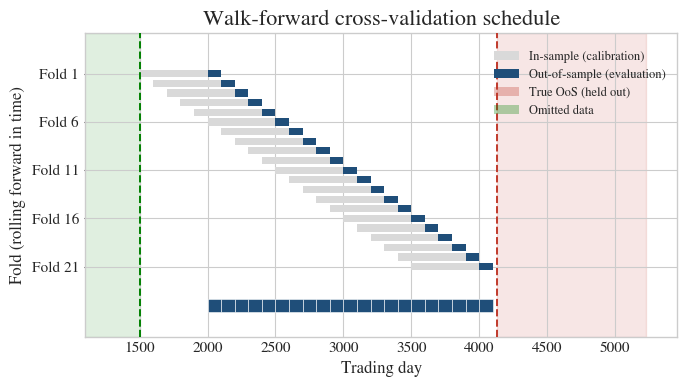

In [22]:
"""
Walk-forward cross-validation schedule figure.

Illustrates the rolling 500-day in-sample / 100-day out-of-sample design
described in the methodology section: 43 non-overlapping OOS folds spanning
~4,900 trading days, concatenated into ~4,300 OOS evaluation days.

Outputs:
    walk_forward_cv.png  (300 dpi raster, for slides / quick previews)
    walk_forward_cv.pdf  (vector, for thesis inclusion)
"""

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# --- Configuration ------------------------------------------------------------

FOLD_START = DATA_START                                         # 1500
FOLD_END   = DATA_START + is_size                               # 4129
IS_LEN  = 500    # in-sample window length (days)
OOS_LEN = 100    # out-of-sample window length (days)
STEP    = 100    # forward step between folds (days)
N_FOLDS = (FOLD_END - FOLD_START - IS_LEN - OOS_LEN) // STEP + 1  # 21

# Colours (academic, print-friendly)
IS_COLOR    = "#d9d9d9"   # light grey for calibration windows
OOS_COLOR   = "#1f4e79"   # deep blue for evaluation windows
EDGE_COLOR  = "white"     # thin separators between concatenated OOS blocks
ANNOT_COLOR    = "#555555"
REAL_OOS_COLOR = "#c0392b"   # red for the true held-out OoS region

# --- Compute fold positions ---------------------------------------------------

folds = []
for k in range(N_FOLDS):
    is_start = FOLD_START + k * STEP
    is_end   = is_start + IS_LEN
    oos_end  = is_end + OOS_LEN
    folds.append((is_start, is_end, oos_end))

# --- Figure -------------------------------------------------------------------

fig, ax = plt.subplots()

bar_h = 0.75
for k, (is_s, is_e, oos_e) in enumerate(folds):
    # Vertical position: fold 1 at top, fold 43 at bottom
    y = N_FOLDS - k
    ax.add_patch(mpatches.Rectangle(
        (is_s, y - bar_h / 2), IS_LEN, bar_h,
        facecolor=IS_COLOR, edgecolor="none"))
    ax.add_patch(mpatches.Rectangle(
        (is_e, y - bar_h / 2), OOS_LEN, bar_h,
        facecolor=OOS_COLOR, edgecolor="none"))

# --- Concatenated OOS strip below the fold stack ------------------------------

strip_y = -3.0
strip_h = 1.4
for k, (is_s, is_e, oos_e) in enumerate(folds):
    ax.add_patch(mpatches.Rectangle(
        (is_e, strip_y - strip_h / 2), OOS_LEN, strip_h,
        facecolor=OOS_COLOR, edgecolor=EDGE_COLOR, linewidth=0.4))

# Bracket the strip
strip_x0 = folds[0][1]
strip_x1 = folds[-1][2]
# ax.annotate(
#     "", xy=(strip_x1, strip_y - strip_h / 2 - 0.4),
#     xytext=(strip_x0, strip_y - strip_h / 2 - 0.4),
#     arrowprops=dict(arrowstyle="-", color=ANNOT_COLOR, linewidth=0.8),
# )
# ax.text(
#     (strip_x0 + strip_x1) / 2, strip_y - strip_h / 2 - 1.3,
#     f"Concatenated out-of-sample evaluation  ({N_FOLDS} × {OOS_LEN} = {N_FOLDS*OOS_LEN:,} days)",
#     ha="center", va="top", fontsize=9, color=ANNOT_COLOR,
# )


# --- True OoS region (held-out 30%) ----------------------------------------
ax.axvspan(0, 1500 , alpha=0.12, color='green', zorder=0,
           label="Omitted data")
ax.axvline(1500, color='green', linewidth=1.4, linestyle="--", zorder=4)


ax.axvspan(4130, 5226 , alpha=0.12, color=REAL_OOS_COLOR, zorder=0,
           label="True OoS")
ax.axvline(4130, color=REAL_OOS_COLOR, linewidth=1.4, linestyle="--", zorder=4)
# --- Annotations on the first fold (window-length labels) ---------------------

y_top = N_FOLDS + 1.6
first = folds[0]

# In-sample bracket
# ax.annotate(
#     "", xy=(first[1], y_top), xytext=(first[0], y_top),
#     arrowprops=dict(arrowstyle="<->", color=ANNOT_COLOR, linewidth=0.8),
# )
# ax.text((first[0] + first[1]) / 2, y_top + 0.35,
#         f"{IS_LEN}-day in-sample",
#         ha="center", va="bottom", fontsize=9, color=ANNOT_COLOR)

# Out-of-sample bracket — pushed higher and connected with a leader line so it
# doesn't overlap the (much wider) IS label above the narrow OOS bar.
y_oos_label = y_top + 1.6
# ax.annotate(
#     "", xy=(first[2], y_top), xytext=(first[1], y_top),
#     arrowprops=dict(arrowstyle="<->", color=ANNOT_COLOR, linewidth=0.8),
# )
oos_mid = (first[1] + first[2]) / 2
# ax.annotate(
#     f"{OOS_LEN}-day OOS",
#     xy=(oos_mid, y_top + 0.1), xytext=(first[2] + 350, y_oos_label),
#     fontsize=9, color=ANNOT_COLOR, ha="left", va="center",
#     arrowprops=dict(arrowstyle="-", color=ANNOT_COLOR, linewidth=0.6),
# )

# --- Step annotation between folds 1 and 2 ------------------------------------

second = folds[1]
y_step = N_FOLDS - 0.5
# ax.annotate(
#     "", xy=(second[0], y_step), xytext=(first[0], y_step),
#     arrowprops=dict(arrowstyle="->", color="#b03a2e", linewidth=0.9),
# )
# ax.text((first[0] + second[0]) / 2, y_step - 0.55,
#         f"step = {STEP} days",
#         ha="center", va="top", fontsize=8, color="#b03a2e")

# --- Axes cosmetics -----------------------------------------------------------

ax.set_xlim(FOLD_START-400, DATA_END + 200)
ax.set_ylim(strip_y - strip_h / 2 - 2.6, y_oos_label + 1.0)

ax.set_xlabel("Trading day")
ax.set_ylabel("Fold (rolling forward in time)")

shown = [0, N_FOLDS // 4, N_FOLDS // 2, 3 * N_FOLDS // 4, N_FOLDS - 1]
ax.set_yticks([N_FOLDS - k for k in shown])
ax.set_yticklabels([f"Fold {k+1}" for k in shown])

# ax.spines["top"].set_visible(False)
# ax.spines["right"].set_visible(False)
# ax.spines["left"].set_visible(False)
ax.tick_params(axis="y", length=1)

# Legend — placed in the upper-right area, well clear of the bottom strip
legend_elements = [
    mpatches.Patch(facecolor=IS_COLOR,  label="In-sample (calibration)"),
    mpatches.Patch(facecolor=OOS_COLOR, label="Out-of-sample (evaluation)"),
    mpatches.Patch(facecolor=REAL_OOS_COLOR, alpha=0.3, label="True OoS (held out)"),
    mpatches.Patch(facecolor='green', alpha=0.3, label="Omitted data")
]
ax.legend(handles=legend_elements, loc="upper right",
          frameon=False, fontsize=9, bbox_to_anchor=(1.0, 0.98))

ax.set_title(
    "Walk-forward cross-validation schedule",
    fontsize=16
)

plt.tight_layout()

# --- Save ---------------------------------------------------------------------

plt.savefig("walk_forward_cv.png", dpi=300, bbox_inches="tight")
plt.savefig("walk_forward_cv.pdf", bbox_inches="tight")

